In [127]:
import warnings
warnings.filterwarnings('ignore')  # oculta la mayoría de warnings

import ast
import pandas as pd
import numpy as np
import re
import requests
import seaborn as sns
import matplotlib.pyplot as plt

from bootcampviztools import plot_grouped_histograms

from bs4 import BeautifulSoup

from catboost import CatBoostRegressor

from kmeanscluster import KMeansCluster

from lightgbm import LGBMRegressor

from optuna import create_study

from sklearn.compose import ColumnTransformer, make_column_selector, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import  KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor

from time import time

from toolbox_ML_v2 import describe_df, tipifica_variables

from utils import extraer_informacion, obtener_urls, aplanar_campos_anidados, crear_features_poi, limpiar_y_crear_features

from xgboost import XGBRegressor

import bootcampviztools as bt

pd.set_option('display.max_columns', 500)

url = 'https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC' # Mapa de la Comunidad de Madrid y alrededores
df = pd.read_csv('../data/pisos_madrid.csv', sep ='|')

# **Extracción de datos**

In [5]:
response = requests.get(url, timeout=10)
soup = BeautifulSoup(response.text, 'html.parser')
ultima = soup.find('a', string='>>')
max_pages = int(re.findall(r'pag-(\d+)', str(ultima))[0])

url_splited = url.split('pag-1')
data = []
for i in range(1, max_pages+1):
    subdata = obtener_urls(f'pag-{i}'.join(url_splited), df)
    data.extend(subdata)

    if len(subdata) < 15:
        break

df = pd.concat([pd.DataFrame(data), df]).reset_index(drop=True)
df.to_csv('../data/pisos_madrid.csv', sep='|', index=False)

Buscando pisos en la página https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC ...
Ya lo tengo: https://www.tecnocasa.es/venta/piso/madrid/madrid/650140.html


## **Objetivo y planteamiento**

El proyecto plantea un problema de **estimación de precios inmobiliarios** a partir de anuncios publicados en la web (Tecnocasa). El objetivo es **predecir el precio de publicación en euros** utilizando información estructural y de contexto disponible en cada anuncio (por ejemplo, superficie, dormitorios, baños, ubicación y atributos del inmueble). Esta estimación permite obtener una referencia rápida del valor esperado en una zona, identificar anuncios potencialmente sobrevalorados o infravalorados y apoyar decisiones de inversión o priorización de búsqueda.

Desde el punto de vista analítico, se trata de un problema adecuado para **Machine Learning** porque el precio depende de múltiples factores que interactúan entre sí y no siguen relaciones estrictamente lineales (por ejemplo, la superficie impacta de forma distinta según la zona; ciertas prestaciones pueden incrementar el precio de manera desigual según el entorno). En este contexto, un enfoque de ML permite aprender patrones a partir de ejemplos reales, generalizar a anuncios nuevos y cuantificar el desempeño del modelo mediante métricas objetivas (RMSE/MAE).

En consecuencia, se adopta un enfoque **supervisado de regresión**, donde la variable objetivo `y` corresponde al **precio en euros** y el conjunto de entrada `X` se construye a partir de variables predictoras derivadas del anuncio, incluyendo variables numéricas y categóricas tras su limpieza y transformación. De forma complementaria, se incorpora una estrategia no supervisada como parte del *feature engineering*: se aplica **K-Means** sobre `latitud` y `longitud` para generar un **cluster geográfico** (`cluster_geo`) que funcione como proxy de “zonas” aprendidas desde los datos. Esto permite resumir patrones espaciales relevantes y capturar efectos de micro-mercado, especialmente útil cuando no se dispone de una variable explícita de barrio o distrito, sin introducir fuga de información al no utilizar variables derivadas del propio precio.

# **Exploración de datos (Comprensión del dataset: esquema, calidad y limpieza inicial)**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1209 entries, 0 to 1208
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   dormitorios         1097 non-null   object 
 1   superficie_m2       1209 non-null   float64
 2   baños               1112 non-null   object 
 3   url                 1209 non-null   object 
 4   features            1209 non-null   object 
 5   descripcion         1209 non-null   object 
 6   precio              1209 non-null   object 
 7   latitud             1209 non-null   float64
 8   longitud            1209 non-null   float64
 9   media               1209 non-null   object 
 10  points_of_interest  1198 non-null   object 
 11  energy_data         1209 non-null   object 
dtypes: float64(3), object(9)
memory usage: 113.5+ KB


In [10]:
df.head()

,dormitorios,superficie_m2,baños,url,features,descripcion,precio,latitud,longitud,media,points_of_interest,energy_data
0,NaN,84.0,NaN,https://www.tecnocasa.es/venta/piso/madrid/nav...,"{'id': 648872, 'floor': '', 'floors': None, 'b...",<p>Inmobiliaria en Navalcarnero El Pinar - La ...,"{'price': '359.900 €', 'box_price': None, 'mor...",40.298202,-3.980352,"{'floor_plans': None, 'has_realistico': False,...","{'public_transport': [{'name': None, 'class': ...","{'class': '', 'class_emissions': None, 'certif..."
1,1 dorm.,44.0,1 baño,https://www.tecnocasa.es/venta/piso/madrid/mad...,"{'id': 650140, 'floor': 2, 'floors': None, 'bo...",<p>Inmobiliaria en zona Vallecas – Portazgo - ...,"{'price': '155.000 €', 'box_price': None, 'mor...",40.393902,-3.660942,"{'floor_plans': None, 'has_realistico': False,...","{'public_transport': [{'name': 'Portazgo', 'cl...","{'class': 'e', 'class_emissions': 'e', 'certif..."
2,NaN,106.0,1 baño,https://www.tecnocasa.es/venta/piso/madrid/mad...,"{'id': 650148, 'floor': 5, 'floors': None, 'bo...",<p>Inmobiliaria en zona VALLECAS – PORTAZGO T...,"{'price': '270.000 €', 'box_price': None, 'mor...",40.398502,-3.651372,"{'floor_plans': None, 'has_realistico': False,...","{'public_transport': [{'name': 'Buenos Aires',...","{'class': 'd', 'class_emissions': 'd', 'certif..."
3,1 dorm.,84.0,1 baño,https://www.tecnocasa.es/venta/piso/madrid/riv...,"{'id': 637551, 'floor': '', 'floors': None, 'b...",<p>Descubre este acogedor estudio en el munici...,"{'price': '230.000 €', 'box_price': None, 'mor...",40.333302,-3.525622,"{'floor_plans': None, 'has_realistico': False,...",{'public_transport': [{'name': 'Rivas Vaciamad...,"{'class': '', 'class_emissions': None, 'certif..."
4,NaN,90.0,1 baño,https://www.tecnocasa.es/venta/piso/madrid/mad...,"{'id': 649701, 'floor': 2, 'floors': None, 'bo...","<p data-start=""90"" data-end=""251"">TECNOCASA GU...","{'price': '569.000 €', 'box_price': None, 'mor...",40.433602,-3.672523,"{'floor_plans': None, 'has_realistico': False,...",{'public_transport': [{'name': 'Diego de León'...,"{'class': 'e', 'class_emissions': 'e', 'certif..."


Tras revisar una muestra inicial del dataset y su estructura general, observamos que el conjunto de datos está compuesto por **12 columnas** y que cada fila representa un anuncio de vivienda obtenido desde la web.

En el bloque de variables básicas de la vivienda contamos con **`dormitorios`**, **`superficie_m2`**, **`baños`**, **`latitud`** y **`longitud`**. En esta primera inspección, **`superficie_m2`** se presenta en un formato directamente utilizable, mientras que **`dormitorios`** y **`baños`** muestran valores “sucios” o inconsistentes (por ejemplo, valores en texto y/o faltantes), por lo que requerirán normalización antes de su uso en el modelado. Las variables geográficas **`latitud`** y **`longitud`** se observan ya en formato numérico (o fácilmente convertible), lo cual permite usarlas directamente como variables geográficas tras una verificación básica de tipos y valores faltantes.

Además, el dataset incluye columnas cuyo contenido no es un valor simple, sino **estructuras semiestructuradas** (diccionarios y/o elementos anidados). En este grupo se encuentran **`features`**, **`precio`**, **`media`**, **`points_of_interest`** y **`energy_data`**, y su tratamiento requerirá primero inspeccionar qué información contienen y cómo se distribuye dentro de sus claves internas.


La columna `url` se utilizará únicamente como identificador operativo durante el proceso (por ejemplo, control de duplicados) y `descripcion` no se empleará en la versión actual del proyecto.

### **Precio**

In [ ]:
df.precio[0]

'{\'price\': \'359.900 €\', \'box_price\': None, \'mortgage_payment\': \'<div class="float-left w-auto">€ 1.159 / mes &nbsp;</div><modal-opener class="modal-opener-nostyle float-left w-auto" name="calculate-mortgage"><img src="/img/icons/info.svg" alt="calcula la hipoteca"></modal-opener>\', \'mortgage_payment_value\': \'1.159\', \'expenses\': None}'

Se observa que `precio` no es un valor escalar sino un **diccionario** con múltiples claves, por ejemplo: `price`, `mortgage_payment`, `mortgage_payment_value`, entre otras.

Para el modelado se decidió **extraer únicamente la clave `price`**, ya que representa el **precio publicado** y se utilizará como **variable objetivo (target)**. El resto de campos del diccionario (por ejemplo, el pago mensual estimado de hipoteca) se descartan deliberadamente porque constituyen **variables derivadas directa o indirectamente del propio precio**.

Incluir variables como `mortgage_payment_value` implicaría una **fuga de información**: el modelo estaría recibiendo como predictor una transformación del target (dependiente del precio y de supuestos financieros), lo que produciría un rendimiento artificialmente alto en entrenamiento/validación y una capacidad de generalización engañosa.  

Por este motivo, se **extrae y normaliza únicamente el valor de `price`** para definir la **variable objetivo `y`** (precio final en euros). A continuación, la columna `precio` (y cualquier componente asociado a cálculos económicos como la hipoteca) **se elimina del dataset de variables predictoras (`X`)** antes de realizar el `train_test_split`, evitando incluir en el entrenamiento información derivada del propio precio (fuga de información / *data leakage*).

### **Dormitorios y baños**

In [14]:
print(df.dormitorios.unique())
print(df.baños.unique())

[nan '1 dorm.' '2 dorm.' '3 dorm.' '4 dorm.' '5 dorm.' '8 dorm.']
[nan '1 baño' '2 baños' '3 baños' '4 baños' '5 baños']


A partir de esta observación, en esta etapa se realiza una **normalización simple**: se elimina el texto asociado (por ejemplo, *“dorm.”*, *“baño/baños”*) y se conserva únicamente el **número**, convirtiéndolo a formato numérico (entero). Los valores faltantes (`NaN`) se mantienen como tales para ser tratados posteriormente en la fase de preparación final de datos.

### **Superficie_m2, latitud y longitud**

In [17]:
df[['superficie_m2', 'latitud' , 'longitud']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1209 entries, 0 to 1208
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   superficie_m2  1209 non-null   float64
 1   latitud        1209 non-null   float64
 2   longitud       1209 non-null   float64
dtypes: float64(3)
memory usage: 28.5 KB


Observamos que **no presentan valores nulos** y que ya se encuentran en formato **`float`**, por lo que **no requieren un preprocesamiento inicial** (más allá de las validaciones generales de rango que se aplican en etapas posteriores).

Aun así, la presencia de **`latitud`** y **`longitud`** aporta una dimensión geoespacial relevante: en mercados inmobiliarios, una parte importante del precio suele estar asociada a la **localización** (micro-zonas, accesibilidad, entorno, etc.). Por este motivo, además de usarlas como variables numéricas directas, se propone generar una variable adicional mediante un enfoque **no supervisado** (K-Means) sobre las coordenadas.

La idea es construir una nueva columna de **cluster geográfico** que actúe como una aproximación a “barrios” o “zonas homogéneas” aprendidas desde los datos. Esto puede ser útil porque:

- **Reduce complejidad espacial**: en lugar de que el modelo tenga que aprender relaciones altamente no lineales con dos coordenadas continuas, el cluster resume patrones geográficos en una variable discreta.
- **Captura efectos de micro-mercado**: viviendas cercanas tienden a compartir características no observadas (servicios, conectividad, prestigio del área, etc.) que impactan el precio, y el clustering puede absorber parte de esa señal.
- **Aporta robustez**: en datasets provenientes de scraping, donde faltan variables “de zona” explícitas, un cluster geográfico puede funcionar como proxy de contexto.
- **Permite interacción con otros atributos**: modelos tipo boosting/árboles pueden combinar el cluster con superficie, dormitorios y baños para capturar reglas distintas según la zona.

Este paso no supervisado se implementa como una transformación adicional en el pipeline, generando una nueva feature que luego se evalúa empíricamente comparando el rendimiento del modelo con y sin dicha variable.

### **Features**

In [29]:
pd.json_normalize(df['features'].apply(lambda x: x if isinstance(x, dict) else (ast.literal_eval(x) if isinstance(x, str) else {}))).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1209 entries, 0 to 1208
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      1209 non-null   int64  
 1   floor                   1209 non-null   object 
 2   floors                  0 non-null      object 
 3   box                     0 non-null      object 
 4   car_places              0 non-null      object 
 5   balconies               0 non-null      object 
 6   terraces                0 non-null      object 
 7   bedrooms                0 non-null      object 
 8   furnitured              0 non-null      object 
 9   air_conditioning        452 non-null    object 
 10  elevator                1209 non-null   object 
 11  heating                 669 non-null    object 
 12  garden                  1209 non-null   object 
 13  category                1209 non-null   object 
 14  build_year              1209 non-null   

La columna `features` contiene información semiestructurada en formato diccionario. Para decidir qué información incorporar al dataset de modelado, primero se inspeccionaron las **claves disponibles** y su **completitud** (cantidad de valores no nulos por clave), con el objetivo de identificar variables que (1) estuvieran suficientemente presentes en el dataset y (2) aportaran señal potencialmente relevante para el precio.

En este análisis se observó que, para ciertas características como **aire acondicionado** y **calefacción**, la ausencia de la prestación se representa como **`None`** (es decir, “no informado / no disponible”), y no como un error de carga o un valor mal formateado. Por lo tanto, estos campos se consideraron aptos para ser extraídos y tratados posteriormente como variables de presencia/ausencia o categóricas, según corresponda.

A partir de este análisis se seleccionaron y extrajeron las siguientes características desde `features`:

- **`planta`** (a partir de `floor`)
- **`aire_acondicionado`** (a partir de `air_conditioning`)
- **`ascensor`** (a partir de `elevator`)
- **`calefaccion`** (a partir de `heating`)
- **`categoria`** (a partir de `category`)
- **`ano_construccion`** (a partir de `build_year`)

Estas variables se incorporan como columnas explícitas en el dataset para su posterior tratamiento (tipado, codificación y manejo de faltantes) dentro del flujo de preparación de datos.

En el caso de **`planta`**, además de valores numéricos, se identificaron **etiquetas textuales** frecuentes (por ejemplo, *“Planta baja/Baja”*, *“Media”*, *“Alta”*, *“Ático”*). Para poder utilizar esta variable de forma consistente, se realizó una **normalización a escala numérica**: se limpiaron los textos y se mapearon categorías a valores ordenables (p. ej., *planta baja → 0*), y para el resto de etiquetas se asignaron valores numéricos representativos basados en la distribución observada (mediana y percentil 75) del componente numérico. De este modo, `planta` queda en un formato comparable dentro del dataset.

Por otro lado, en **`categoria`**, se decidió aplicar una **codificación ordinal** para reflejar que no todas las categorías son equivalentes en términos de precio.El orden de la codificación no se eligió de forma arbitraria: se estimó empíricamente calculando la **media del precio por categoría** (mediante un `groupby` de `categoria` agrupando por `y`/precio). A partir de esas medias se observó un gradiente coherente:

- **`Popular`** y **`Media`** presentaban medias muy similares (mismo nivel).
- **`De época`** mostraba una media superior.
- **`Señorial`** concentraba los valores más altos.

Por este motivo se asignó un orden creciente de “nivel” (por ejemplo, `Popular/Media` < `De época` < `Señorial`) y se transformó a una variable numérica ordinal (`categoria_ord`) para que el modelo pueda interpretar esa jerarquía.

### **Media**

In [30]:
pd.json_normalize(df['media'].apply(lambda x: x if isinstance(x, dict) else (ast.literal_eval(x) if isinstance(x, str) else {}))).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1209 entries, 0 to 1208
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   floor_plans     208 non-null    object 
 1   has_realistico  1209 non-null   bool   
 2   has_smartvt360  1209 non-null   bool   
 3   images          1209 non-null   object 
 4   images_ai       90 non-null     object 
 5   video           14 non-null     object 
 6   virtual_tour    72 non-null     object 
 7   map.latitude    1209 non-null   float64
 8   map.longitude   1209 non-null   float64
 9   map.exact       1209 non-null   bool   
dtypes: bool(3), float64(2), object(5)
memory usage: 69.8+ KB


La columna `media` contiene información semiestructurada en formato diccionario sobre recursos multimedia del anuncio. Al igual que con `features`, primero se inspeccionaron las **claves disponibles** y su **completitud** para identificar qué campos eran suficientemente frecuentes y potencialmente útiles para el modelo.

A partir de este análisis se seleccionaron y extrajeron las siguientes variables:

- **`planos`**: indicador de presencia de planos (derivado de `floor_plans`)
- **`realista`**: indicador de contenido “realístico” (derivado de `has_realistico`)
- **`fotografias`**: cantidad de imágenes disponibles en el anuncio (derivado de `images`)

### **Points_of_interest**

In [34]:
pd.json_normalize(df['points_of_interest'].apply(lambda x: x if isinstance(x, dict) else (ast.literal_eval(x) if isinstance(x, str) else {}))).head(1)

,public_transport,school,market,shop,bar,restaurant,pharmacy,hospital
0,"[{'name': None, 'class': 'bus', 'subclass': 'b...","[{'name': 'C.E.I.P. María Martín', 'class': 's...","[{'name': 'Aldi', 'class': 'grocery', 'subclas...","[{'name': 'Tony', 'class': 'shop', 'subclass':...","[{'name': 'El Secreto', 'class': 'bar', 'subcl...","[{'name': 'Sushi Shop', 'class': 'restaurant',...",NaN,NaN


La columna `points_of_interest` contiene información semiestructurada donde cada **clave** (por ejemplo, `school`, `public_transport`, `pharmacy`, `hospital`, etc.) corresponde a un tipo de punto de interés. El valor asociado a cada clave es una **lista de diccionarios**, y cada diccionario representa un POI individual con atributos como nombre/tipo y, especialmente, **distancia**.

Dado que el modelo requiere variables numéricas y comparables, se decidió conservar **todos los tipos de POI disponibles** y resumir cada uno mediante dos métricas por vivienda:

1. **Cantidad de POIs (`*_cnt`)**: número de elementos dentro de la lista (equivalente al número de puntos de interés detectados para esa categoría).
2. **Distancia mínima en metros (`*_min_dist_m`)**: se toma la distancia reportada por los POIs, se estandariza su unidad (convirtiendo valores en km y m a un único formato en **metros**) y se calcula la distancia mínima, asumiendo que el POI más cercano es el más relevante para capturar accesibilidad.

Cuando una vivienda no presenta POIs para una categoría determinada (lista vacía o ausencia de la clave), la distancia mínima se imputó con **10.000 metros**. Esta decisión se tomó para representar explícitamente “no hay POIs cercanos” y evitar confundir ausencia con un valor numérico bajo; además, en la web el mayor valor de distancia observado era aproximadamente **3.000 metros**, por lo que 10.000 m funciona como un valor claramente fuera de rango que marca lejanía/no disponibilidad.

### **Energy_data**

In [35]:
pd.json_normalize(df['energy_data'].apply(lambda x: x if isinstance(x, dict) else (ast.literal_eval(x) if isinstance(x, str) else {}))).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1209 entries, 0 to 1208
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   class                 1209 non-null   object
 1   class_emissions       823 non-null    object
 2   certification_date    95 non-null     object
 3   certification_number  63 non-null     object
 4   certification_type    1209 non-null   object
 5   efficiency            823 non-null    object
 6   emissions             823 non-null    object
 7   ep_nren               0 non-null      object
 8   ep_ren                0 non-null      object
 9   icone                 823 non-null    object
 10  icone_emissions       823 non-null    object
 11  smile_ce              0 non-null      object
 12  smile_ci              0 non-null      object
 13  building_state        1209 non-null   object
 14  heating               0 non-null      object
 15  heating_type          1209 non-null   

La columna `energy_data` contiene información semiestructurada en formato diccionario sobre la certificación energética del inmueble. Siguiendo el mismo criterio aplicado en `features` y `media`, primero se inspeccionaron las claves disponibles y su completitud, y luego se seleccionaron aquellas variables energéticas con mayor relevancia potencial para el precio.

A partir de `energy_data` se extrajeron las siguientes columnas:

- **`clase_energetica`** (desde `class_emissions`)
- **`eficiencia_energetica`** (desde `efficiency`)
- **`emisiones_energeticas`** (desde `emissions`)

Dado que la **clase energética** sigue una escala ordenada (A–G), se incorporó una transformación adicional de **codificación ordinal**, convirtiendo las letras en un valor numérico que preserva el orden (por ejemplo, `A → 6`, …, `G → 0`). Esto permite que el modelo interprete correctamente que no se trata de categorías “sin relación”, sino de niveles comparables de desempeño energético.

Finalmente, debido a que una proporción de anuncios no informa certificación, los valores faltantes no se imputaron directamente en la escala ordinal. En su lugar, se creó una variable adicional **`tiene_certificado`**, que indica si el inmueble cuenta o no con certificación energética informada, dejando el faltante explícito y separando “ausencia de dato” de “mala clasificación energética”.

# **Train test split**

In [36]:
X = df.drop(columns='precio')
y = df['precio'].astype(str).str.extract(r'([\d\.]+) €').replace(r'\.', '', regex=True).astype(int)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(967, 11)
(242, 11)
(967, 1)
(242, 1)



Una vez definido el **precio en euros** como variable objetivo, se separó el dataset en:

- **`X`**: conjunto de variables predictoras, eliminando la columna `precio`.
- **`y`**: variable objetivo, construida a partir de `precio` tras su normalización a formato numérico.

A continuación, se realizó la partición **train/test** con un **80/20** (`test_size=0.2`) y una semilla fija (`random_state=42`) para garantizar reproducibilidad. Como resultado, el conjunto de entrenamiento quedó con **967 registros** y el de test con **242 registros**, manteniendo las **11 variables predictoras** en ambos subconjuntos.

# **Clustering No Supervisado**  
La ubicación es uno de los factores que más influye en el precio, y en este dataset no contamos con una variable explícita de “zona/barrio”. Por ello aplicamos **K-Means** sobre `latitud` y `longitud` para generar un **cluster geográfico** que actúe como proxy de zonas homogéneas. Esta nueva variable se incorpora luego como *feature* adicional para evaluar si mejora el rendimiento del modelo de regresión.

In [40]:
coordenadas = X_train[['latitud','longitud']]

### **Escalado de coordenadas**

Antes de aplicar K-Means, se realiza un **escalado** de `latitud` y `longitud` con `StandardScaler`. Esto es importante porque K-Means asigna clusters minimizando **distancias** (euclídeas) entre puntos y centroides. Si una variable tuviera mayor magnitud o dispersión que la otra, dominaría el cálculo de distancias y el algoritmo priorizaría esa dimensión de forma desbalanceada. Al estandarizar (media 0, desvío 1), ambas coordenadas contribuyen de manera comparable a la formación de los clusters y se evita que el resultado dependa de la escala numérica en lugar de la estructura espacial real.

In [68]:
scaler = StandardScaler()
coords = scaler.fit_transform(coordenadas)

### **Selección del número de clusters (`k`)**

Para definir un valor razonable de `k` en K-Means se utilizaron dos criterios complementarios: **inercia** (método del codo) y **silhouette score**. La inercia permite identificar a partir de qué punto aumentar `k` aporta mejoras marginales en la compactación de los clusters, mientras que el *silhouette* evalúa la calidad de la partición midiendo simultáneamente cohesión intra-cluster y separación entre clusters. Ambos análisis se interpretan en conjunto (y se apoyan con inspección visual) para elegir un `k` final que equilibre calidad y interpretabilidad. promedio, qué tan **compactos** son los clusters y qué tan **separados** quedan entre sí (valores más altos indican una partición más clara).

In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = []
inertias = []
sil_scores = []
k_range = range(2,12)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=25)
    kmeans.fit(coords)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(coordenadas, kmeans.labels_))
    ks.append(k)

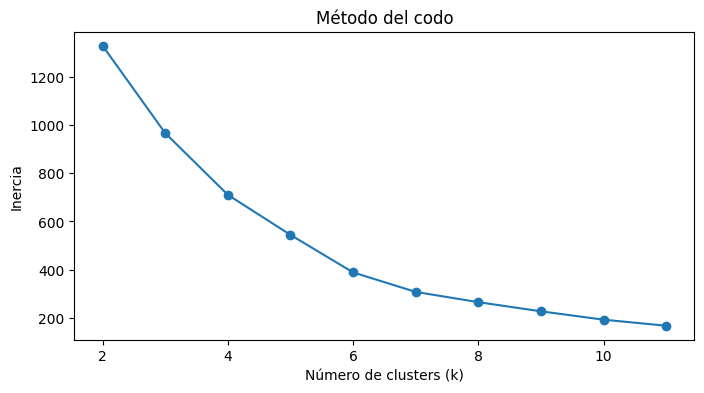

In [9]:
plt.figure(figsize=(8,4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

En el gráfico se observa una caída marcada de la inercia en los primeros valores de `k` y un aplanamiento progresivo a partir de un valor intermedio, lo que sugiere que incrementar `k` más allá de ese punto aporta segmentaciones cada vez más finas pero con menor ganancia en compactación. Por este motivo, la inercia se utiliza como criterio orientativo para acotar un rango razonable de `k`, que luego se complementa con *silhouette score* e inspección visual de los clusters.

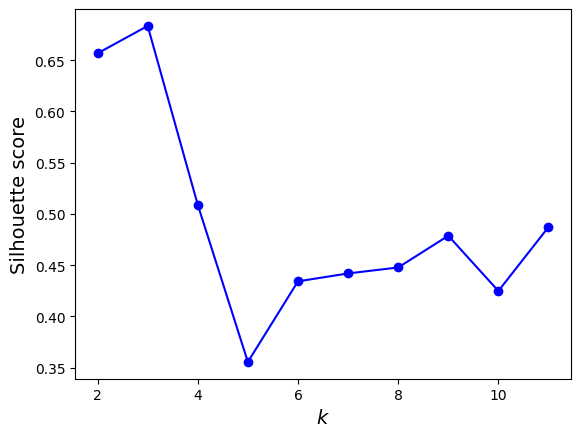

In [8]:
plt.plot(ks, sil_scores, "bo-");
plt.xlabel("$k$", fontsize=14);
plt.ylabel("Silhouette score", fontsize=14)
plt.show()

En el gráfico se observa un valor alto para **k=2–3**, con un **máximo alrededor de k=3**, lo que sugiere que el dataset admite una separación bastante nítida en pocos grupos “grandes”. A partir de **k≥4** el *silhouette* desciende de forma marcada y luego se mantiene en valores moderados, lo que indica que aumentar el número de clusters tiende a generar particiones más finas pero menos claramente separadas. Por este motivo, el *silhouette* se utilizó como criterio complementario al método del codo y a la inspección visual de los clusters para elegir el `k` final.

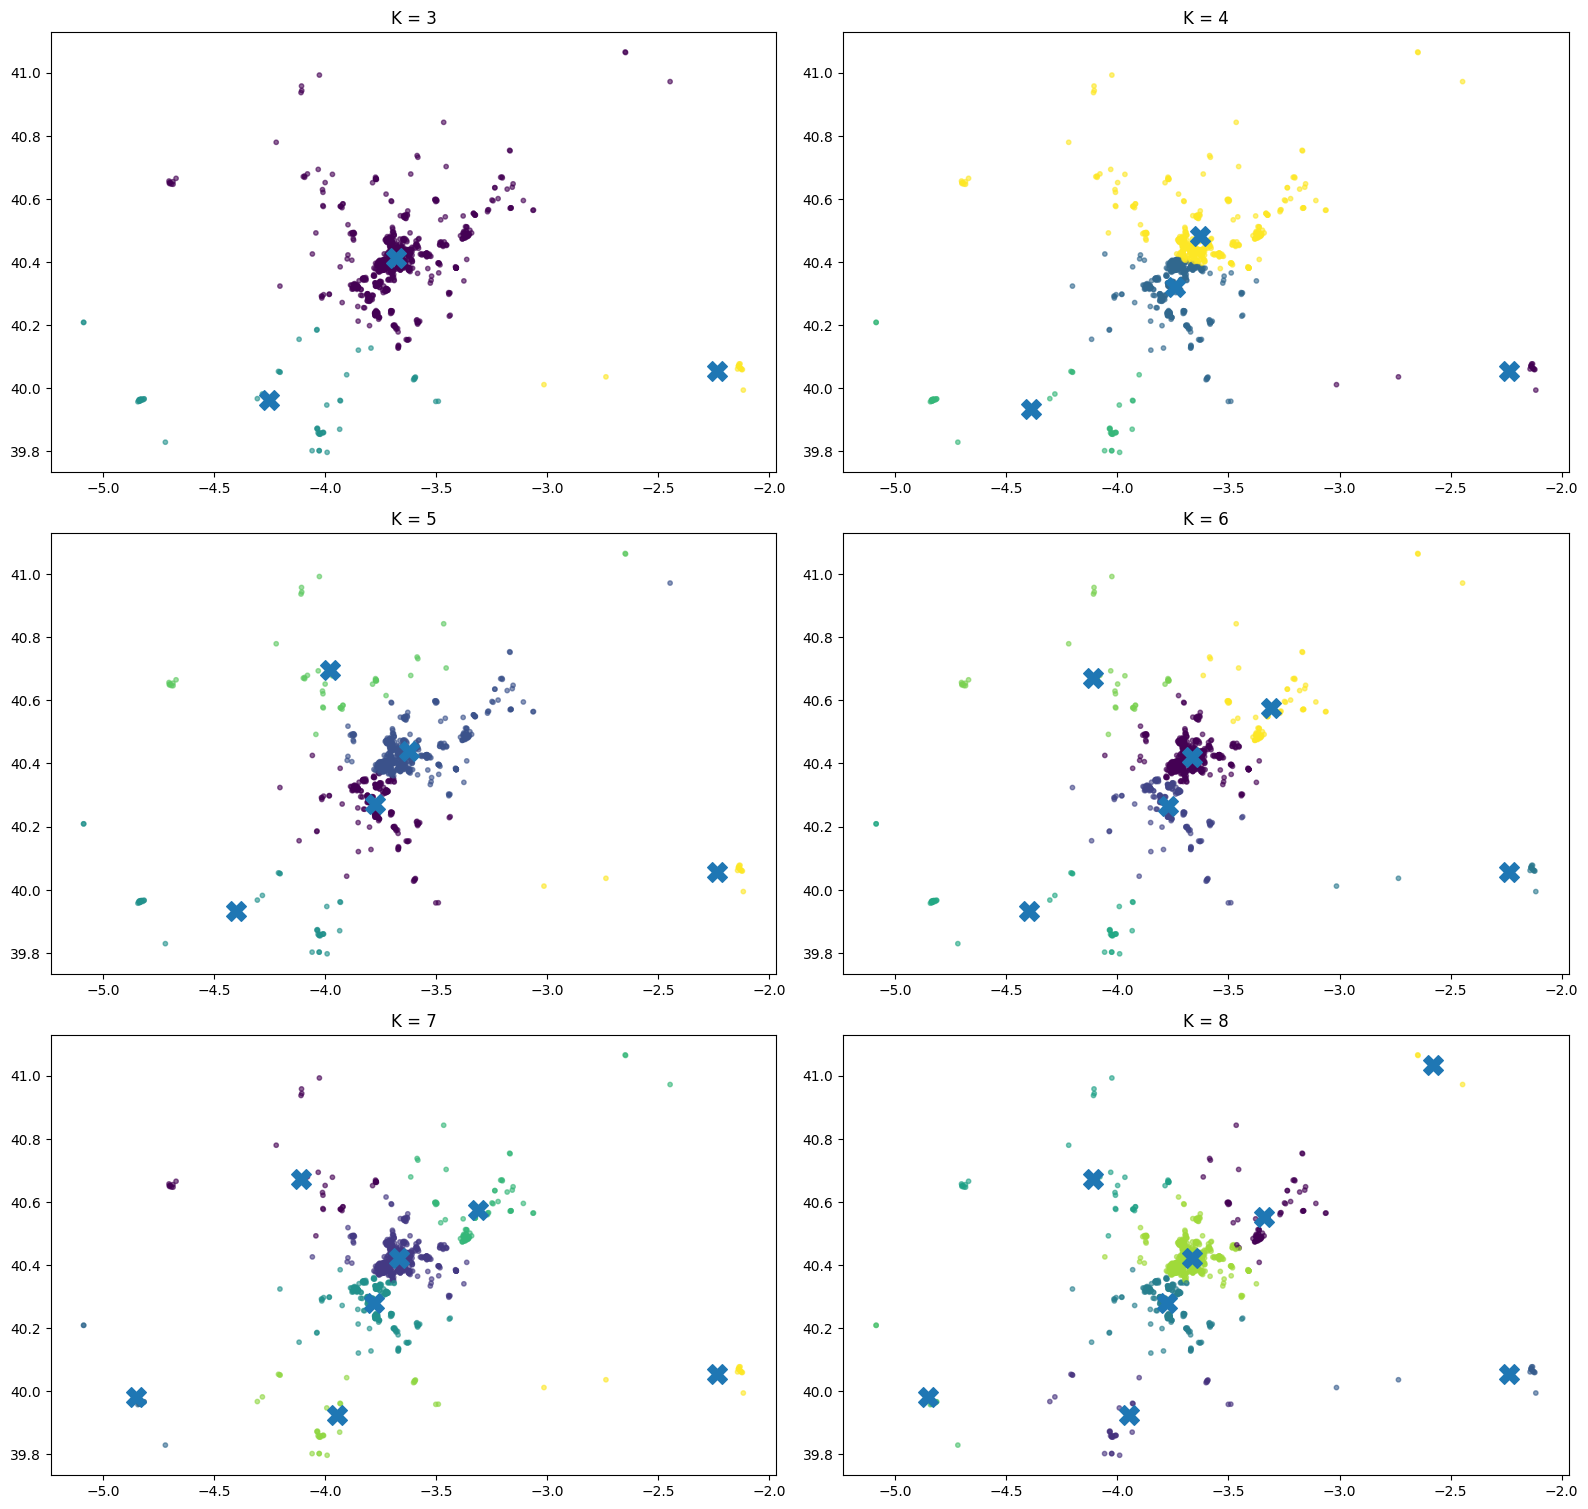

In [10]:
k_values = [3,4,5,6,7,8]

plt.figure(figsize=(16,30))

for i, k in enumerate(k_values):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = kmeans.fit_predict(coords)
    
    centroids = scaler.inverse_transform(kmeans.cluster_centers_)

    plt.subplot(6,2,i+1)

    plt.scatter(
        X_train['longitud'],
        X_train['latitud'],
        c=labels,
        s=10,
        alpha=0.6
    )

    plt.scatter(
        centroids[:,1],
        centroids[:,0],
        marker='X',
        s=200
    )

    plt.title(f"K = {k}")

plt.tight_layout()
plt.show()

Como paso final, se visualizaron los clusters geográficos para distintos valores (`k = 3, 4, 5, 6, 7, 8`) y se evaluó la **coherencia espacial** de las particiones. Más allá de las métricas (inercia y *silhouette*), esta inspección permite verificar que los grupos resultantes tengan sentido práctico como aproximación a “zonas” dentro de Madrid.

Integrando (1) los resultados cuantitativos de inercia y *silhouette* y (2) la interpretabilidad de los mapas de clusters apoyada en conocimiento general de la ciudad (zonas y gradientes de coste), se seleccionó **`k = 5`** como configuración final, por ofrecer un equilibrio entre separación razonable y segmentación no excesiva. A partir de esta elección se generó la variable `cluster`, que se incorpora como feature adicional para evaluar su impacto en el modelo supervisado.  
 **ELIGIRIA K = 6**

In [50]:
k = 6

kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=50)
kmeans_final.fit(coords)

KMeans(n_clusters=6, n_init=50, random_state=42)

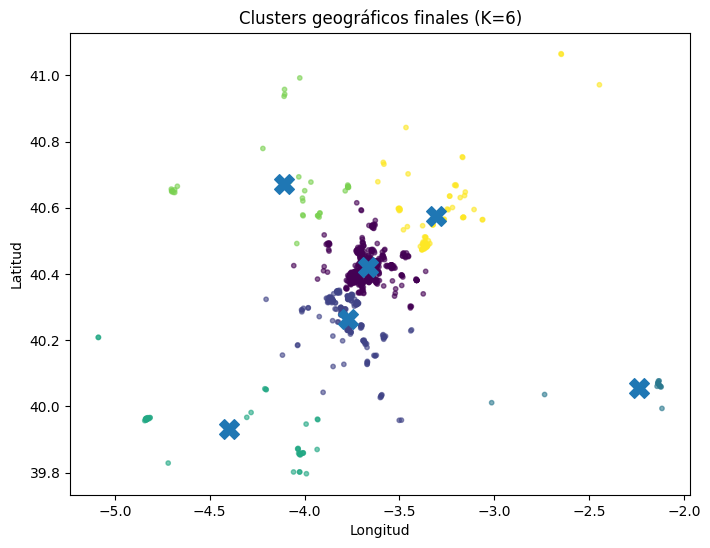

In [51]:
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
clusters = kmeans_final.predict(coords)

plt.figure(figsize=(8,6))

plt.scatter(
    X_train['longitud'],
    X_train['latitud'],
    c=clusters,
    s=10,
    alpha=0.6
)

plt.scatter(
    centroids[:,1],
    centroids[:,0],
    marker='X',
    s=200
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title(f"Clusters geográficos finales (K={k})")
plt.show()

# **Pretratamiento de datos**

In [59]:
cluster_transformer = ColumnTransformer(
    [
        ('cluster', KMeansCluster(n_clusters=6), ['latitud','longitud'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [60]:
DROP_COLS = ['url', 'features', 'descripcion', 'precio', 'media', 'points_of_interest',
             'energy_data', 'transporte_publico', 'escuelas', 'farmacias', 'hospitales',
             'supermercados', 'tiendas', 'bares', 'restaurantes']
drop_step = FunctionTransformer(
    lambda df: df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
)

In [62]:
pipe_features = Pipeline([
    ('aplanar_campos', FunctionTransformer(aplanar_campos_anidados)),        
    ('poi_features', FunctionTransformer(crear_features_poi)),          
    ('final_clean', FunctionTransformer(limpiar_y_crear_features)),
    ('cluster', cluster_transformer),
    ('drop',drop_step)
])

X_train_limpio = pipe_features.fit_transform(X_train)
X_train_limpio.head()

c:\Users\Usuario\Desktop\data_science\Bootcamp_TheBridge\ML_Prediccion_Precio_Vivienda_Madrid\src\cajon_basura\utils.py:265: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,latitud,longitud,cluster,dormitorios,superficie_m2,baños,planta,aire_acondicionado,ascensor,calefaccion,ano_construccion,planos,realista,fotografias,eficiencia_energetica,emisiones_energeticas,tp_cnt,tp_min_dist_m,esc_cnt,esc_min_dist_m,fca_cnt,fca_min_dist_m,hosp_cnt,hosp_min_dist_m,super_cnt,super_min_dist_m,tda_cnt,tda_min_dist_m,bar_cnt,bar_min_dist_m,resto_cnt,resto_min_dist_m,calefaccion_gas,calefaccion_electrica,categoria_ord,clase_energetica_ord,tiene_certificado
1055,40.489602,-3.886053,B,2.0,120.0,1.0,NaN,Independiente,1,Independiente,1990,1,False,29,240.6,50.4,3,140.0,5,320.0,5,770.0,1,2100.0,5,720.0,5,710.0,5,180.0,5,610.0,0,0,0,2.0,True
666,40.446802,-3.703233,B,2.0,42.0,1.0,2.0,Independiente,0,None,1925,0,False,22,162.0,34.0,5,60.0,5,150.0,5,50.0,5,380.0,5,110.0,5,40.0,5,100.0,5,50.0,0,0,0,2.0,True
1014,40.494502,-3.693703,B,4.0,88.0,2.0,5.0,None,1,None,1979,0,False,24,294.0,61.0,5,40.0,5,60.0,5,70.0,5,890.0,5,220.0,5,340.0,5,330.0,5,310.0,0,0,0,2.0,True
650,40.484702,-3.359223,E,2.0,80.0,1.0,0.0,Independiente,0,Independiente,1965,0,True,24,NaN,NaN,4,90.0,5,60.0,5,150.0,5,740.0,5,170.0,5,90.0,5,150.0,5,150.0,0,1,0,NaN,False
899,40.435002,-3.706983,B,5.0,152.0,2.0,5.0,Centralizada,0,centralizada,1940,0,False,29,174.0,36.0,5,130.0,5,110.0,5,100.0,5,400.0,5,40.0,5,190.0,5,100.0,5,30.0,1,0,2,2.0,True


# **MiniEDA**

In [80]:
train_set = X_train_limpio.copy()
train_set['Precio'] = y_train.values  
target = 'Precio'

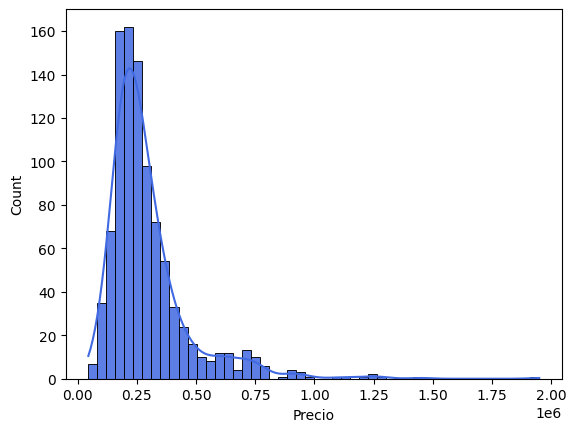

In [92]:
sns.histplot(train_set['Precio'], bins=50, kde=True, color='royalblue', alpha=0.85)
plt.show()

Distribución del precio con cola derecha pronunciada: la mayoría de viviendas se concentra entre ~200k y ~350k, pero hay un grupo pequeño de anuncios muy caros (outliers) que estiran la cola hasta ~2M.

In [64]:
X_train_limpio.shape

(967, 37)

In [65]:
describe_df(X_train_limpio).T

Clasificación sugerida para 967 filas, con un umbral para categórica nominal de 10 sobre la cardinalidad y un umbral para númerica continua de 10.0 % sobre la cardinalidad relativa.


Columnas,Tipo_Dato,Nulos,Nulos_%,Cardinalidad,Cardinalidad_%,Clasificacion_sugerida
latitud,float64,0,0.0,833,86.14,Numerica_Continua
longitud,float64,0,0.0,945,97.72,Numerica_Continua
cluster,object,0,0.0,6,0.62,Categorica
dormitorios,float64,93,9.6,6,0.62,Categorica
superficie_m2,float64,0,0.0,159,16.44,Numerica_Continua
baños,float64,82,8.5,5,0.52,Categorica
planta,float64,365,37.7,13,1.34,Numerica_Discreta
aire_acondicionado,object,0,0.0,3,0.31,Categorica
ascensor,int64,0,0.0,2,0.21,Categorica_Binaria
calefaccion,object,0,0.0,3,0.31,Categorica


In [66]:
binaria = tipifica_variables(X_train_limpio)['Categorica_Binaria']
categoricas = tipifica_variables(X_train_limpio)['Categorica']
num_discreta = tipifica_variables(X_train_limpio)['Numerica_Discreta']
num_continua = tipifica_variables(X_train_limpio)['Numerica_Continua']
numericas = num_discreta + num_continua

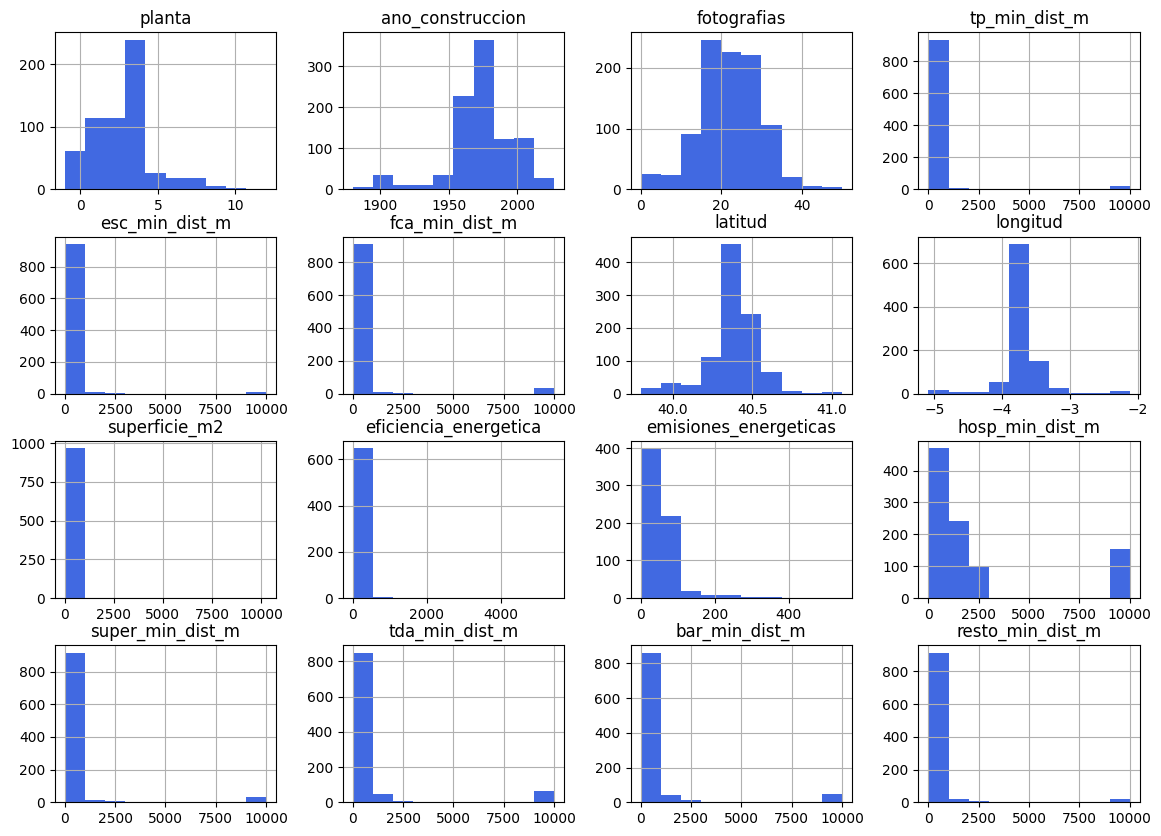

In [94]:
X_train_limpio[numericas].hist(figsize=(14, 10), color='royalblue');

Acá simplemente visualizamos los histogramas de las variables numéricas ya limpias para ver cómo se distribuyen. En esta etapa **no aplicamos transformaciones logarítmicas a las features**, porque más adelante vamos a usar modelos tipo árboles/boosting que no necesitan que las variables sigan una distribución “normal”. Se nota que varias distancias a POIs se acumulan cerca de 0 y también aparece un pico en **10.000 m**, que corresponde al valor que usamos para marcar que **no hay puntos de interés cercanos**. Con el **precio** sí tiene sentido mirar también una versión en escala log más adelante, porque suele estar muy sesgado y con outliers.

## **Analisis bivariante**

### Target contra variables **categóricas, ordinales y binarias**

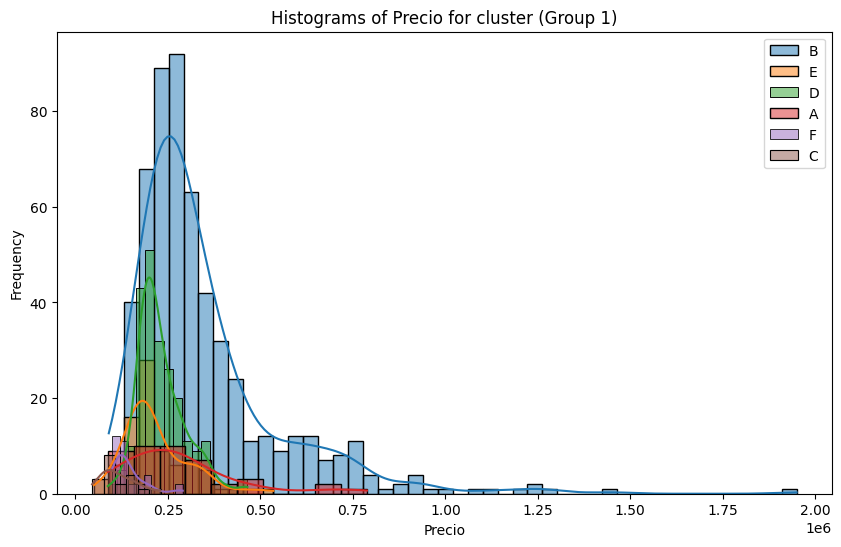

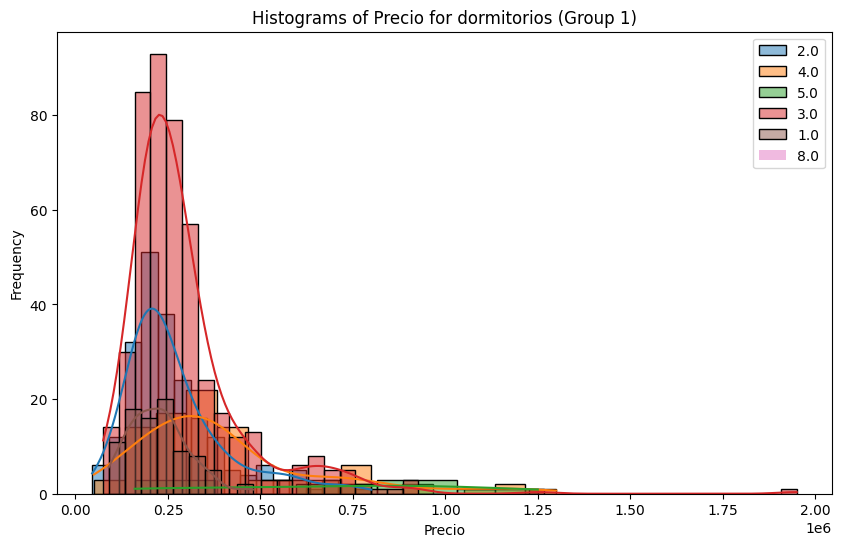

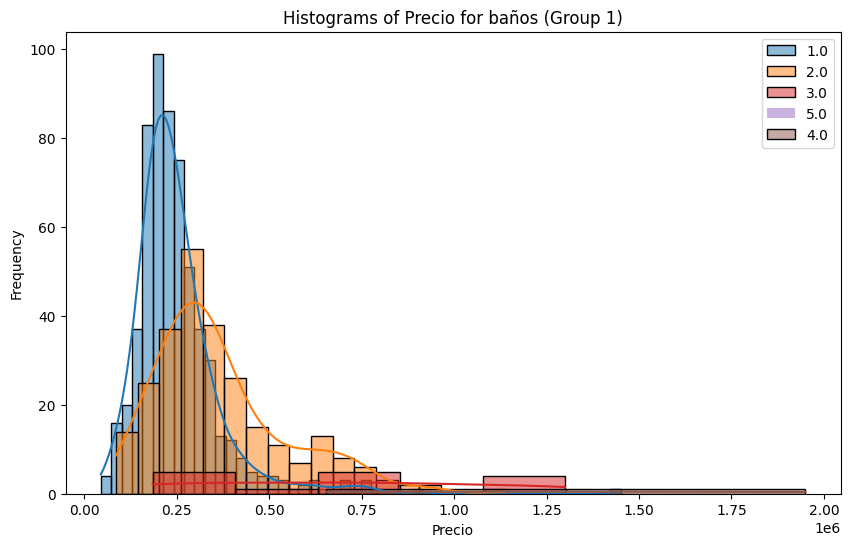

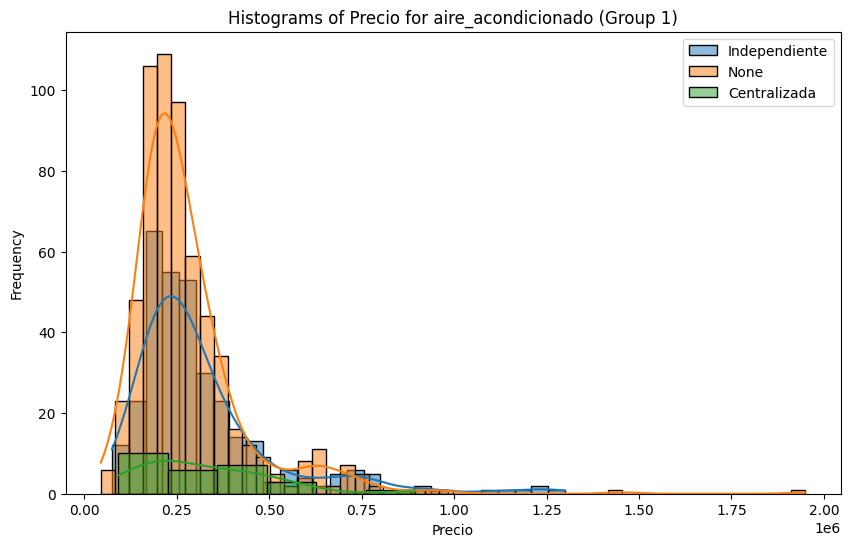

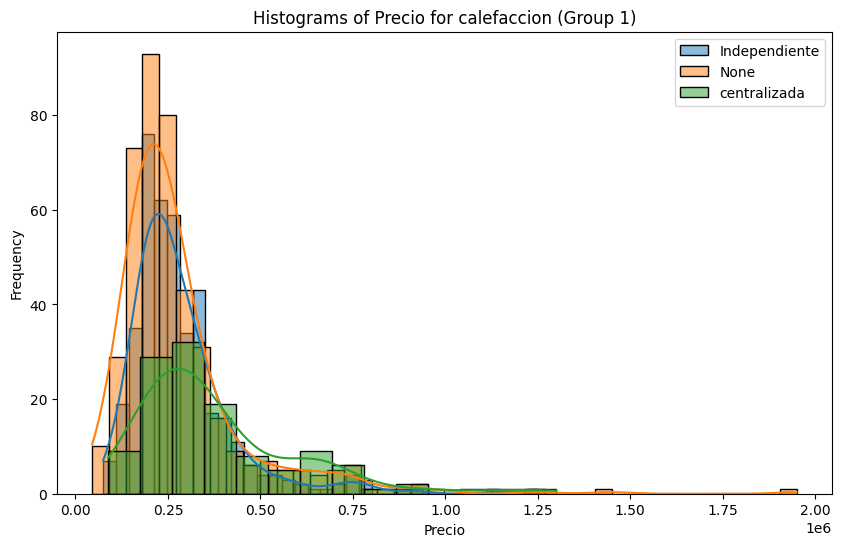

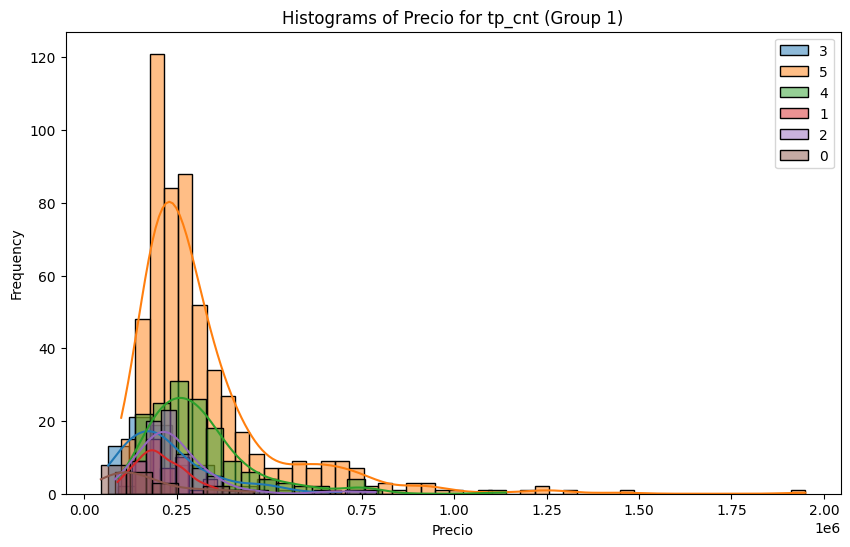

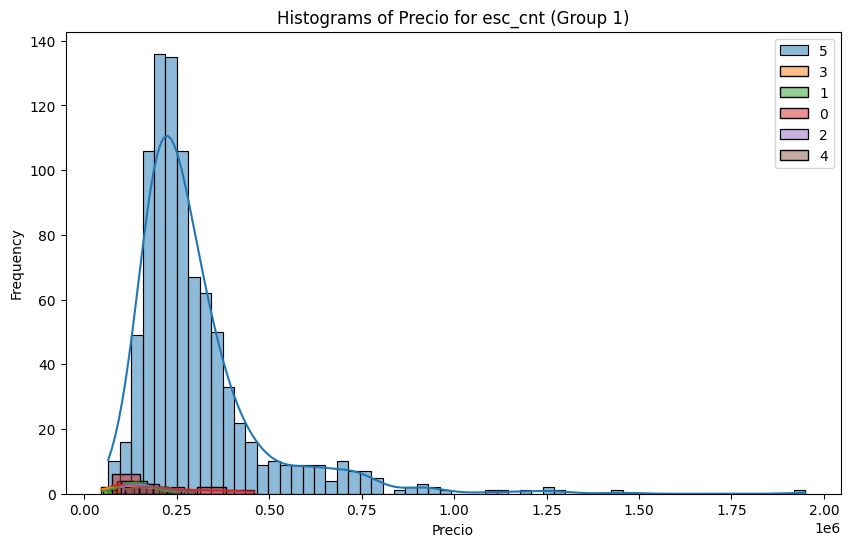

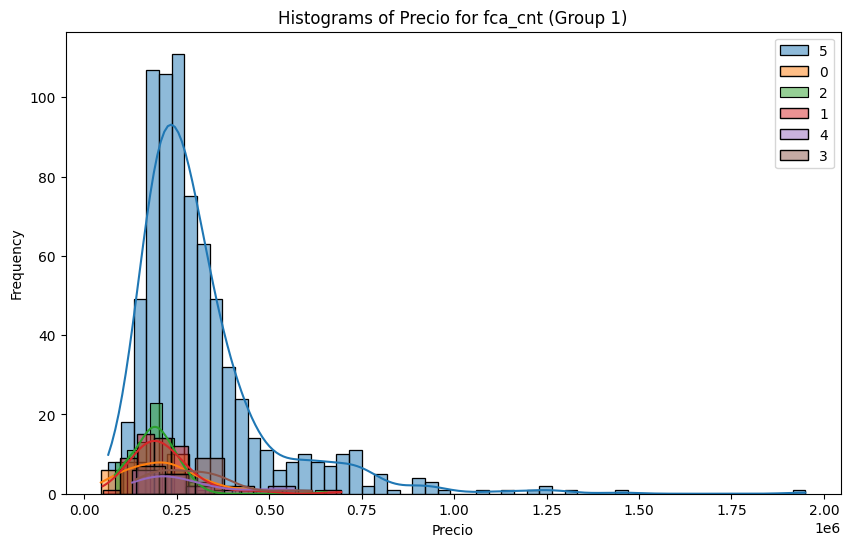

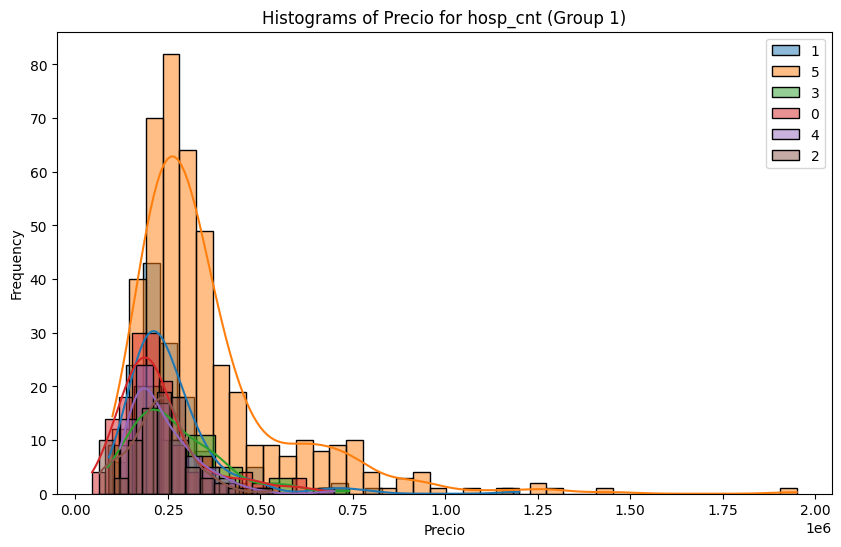

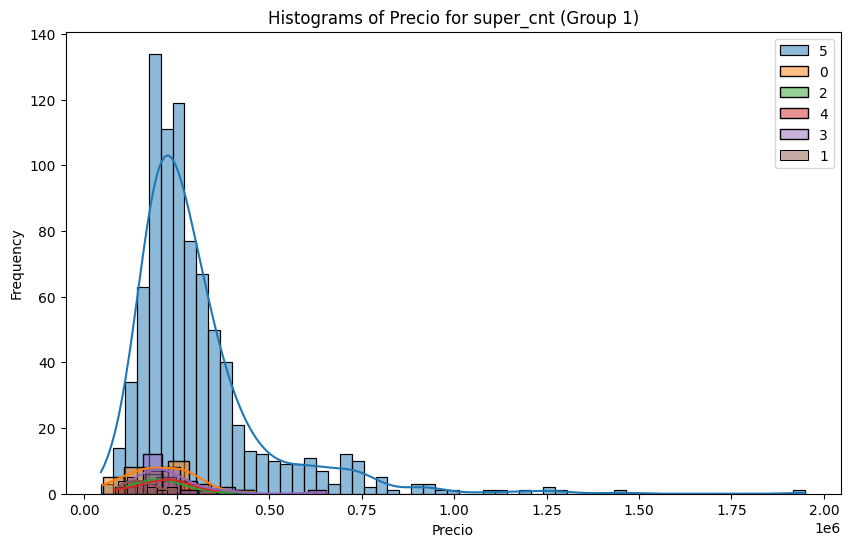

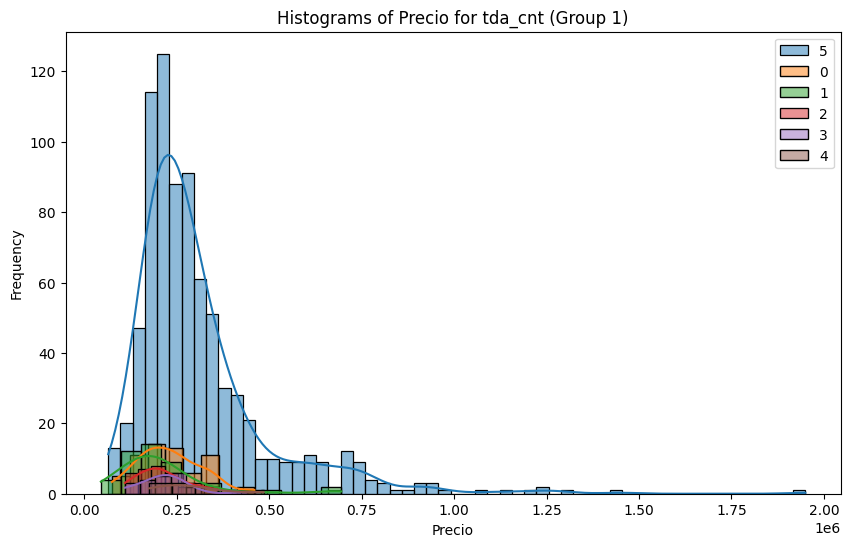

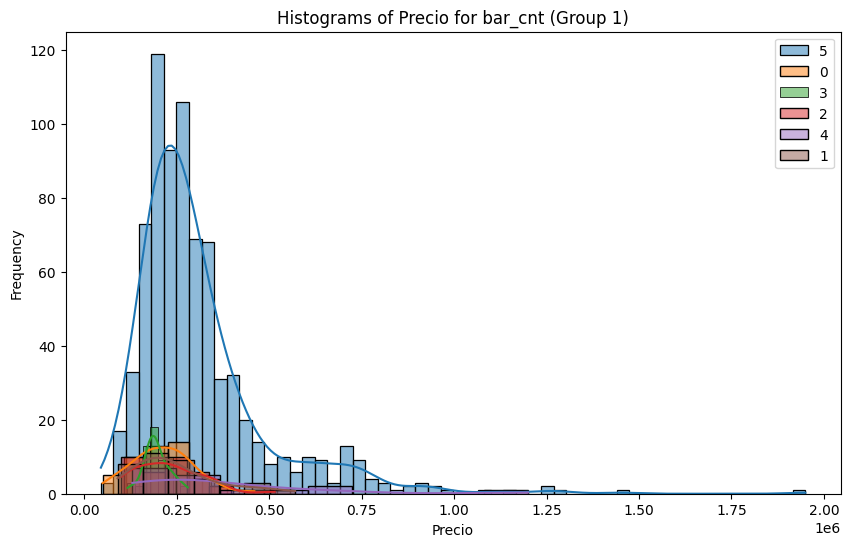

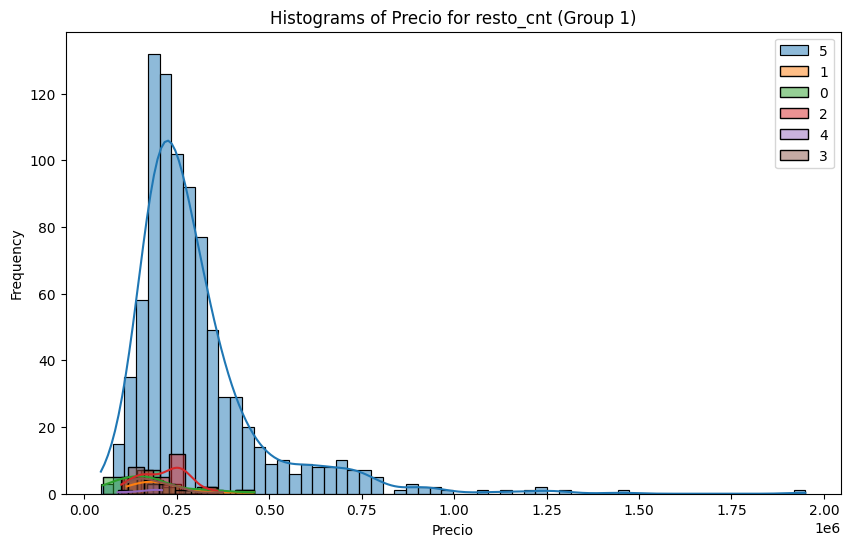

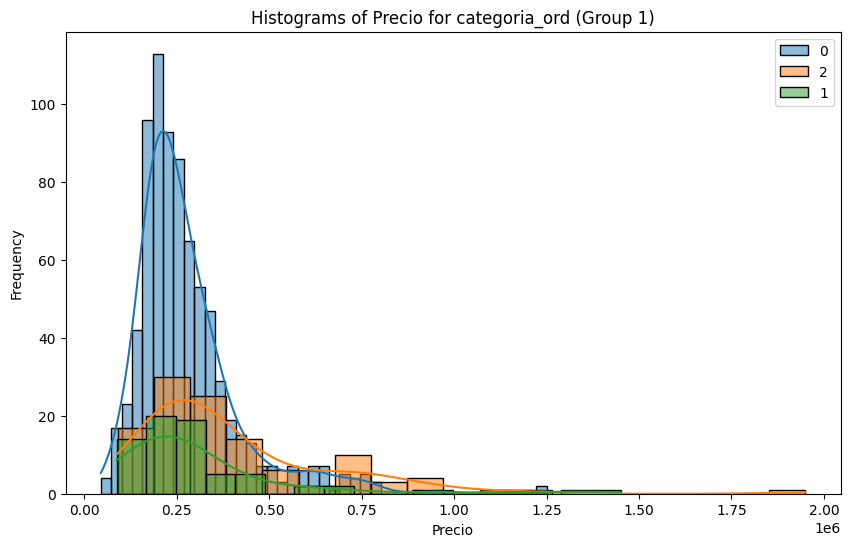

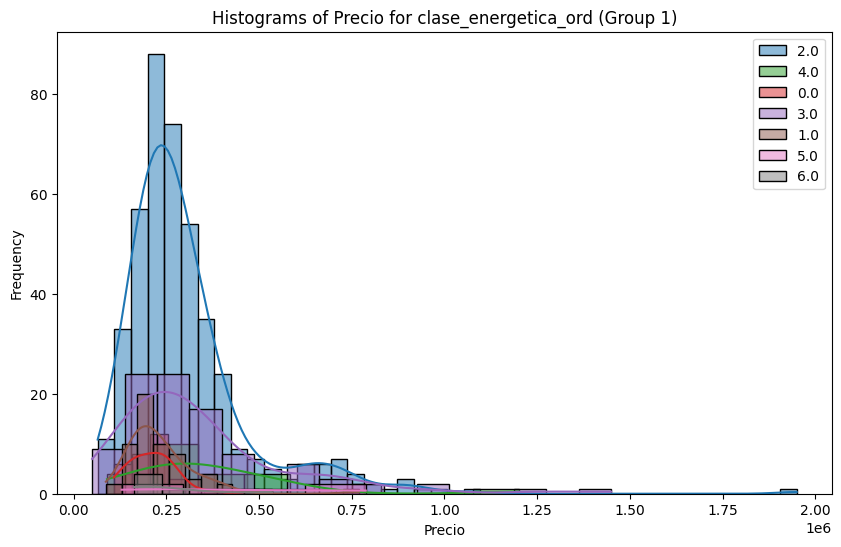

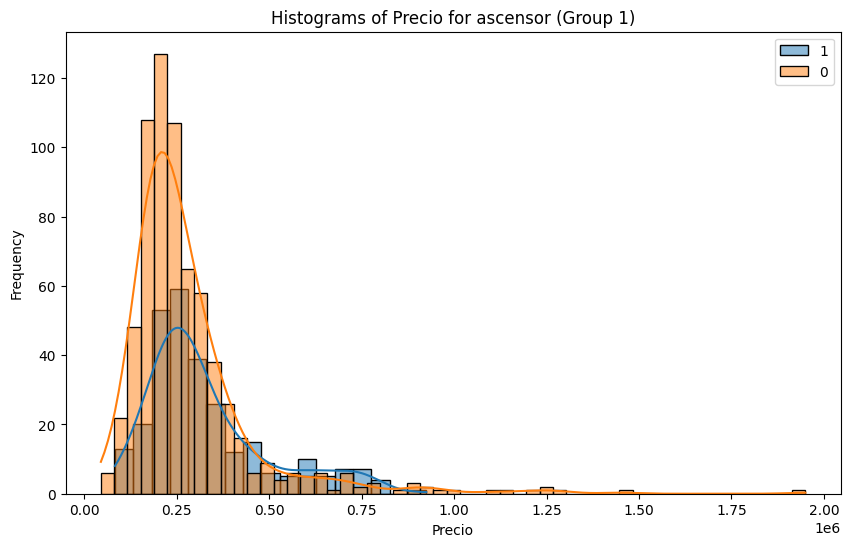

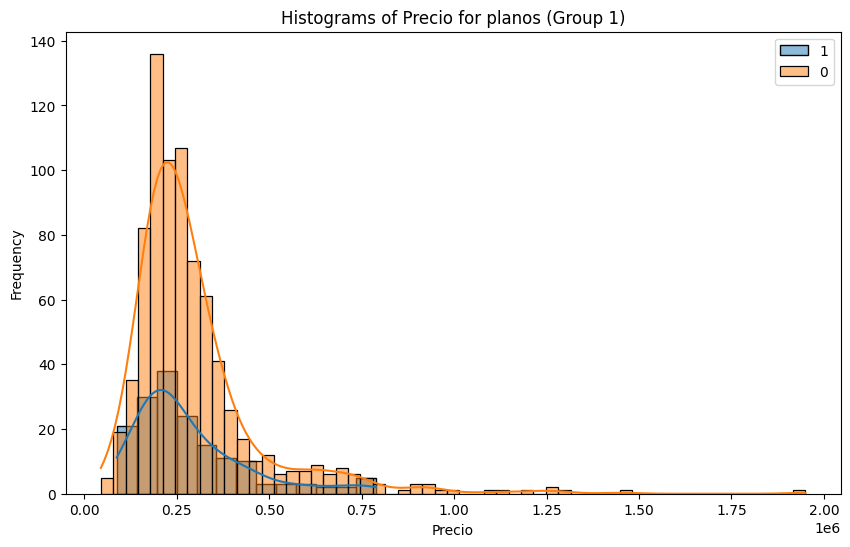

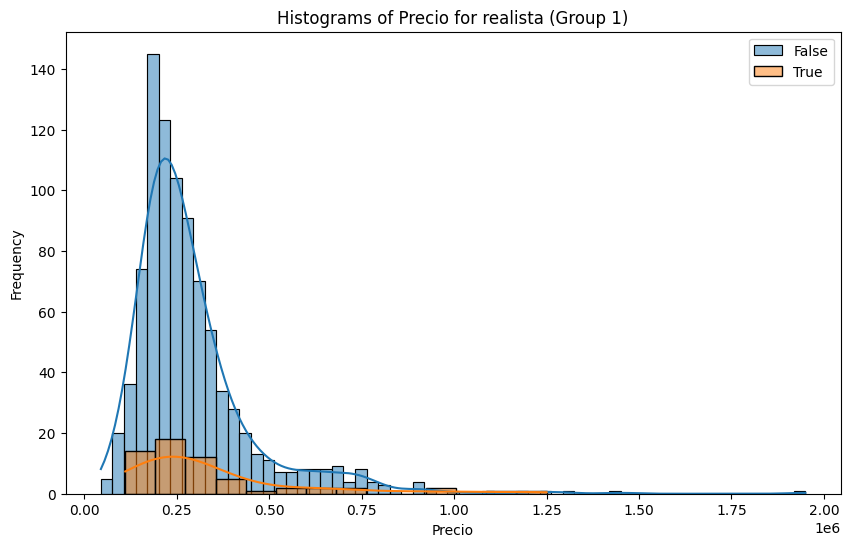

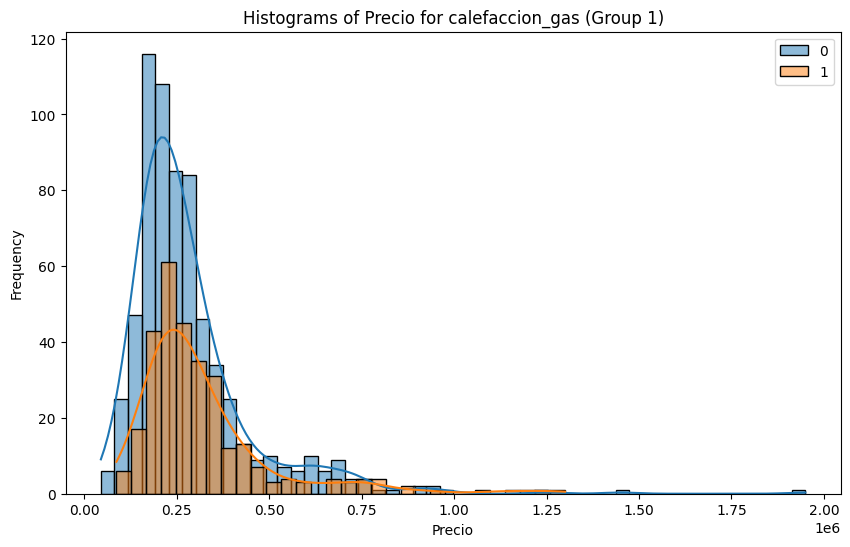

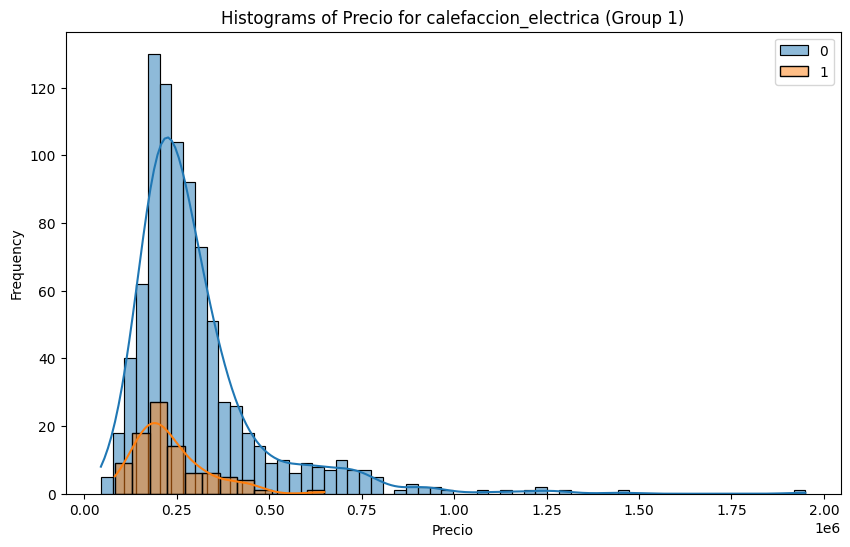

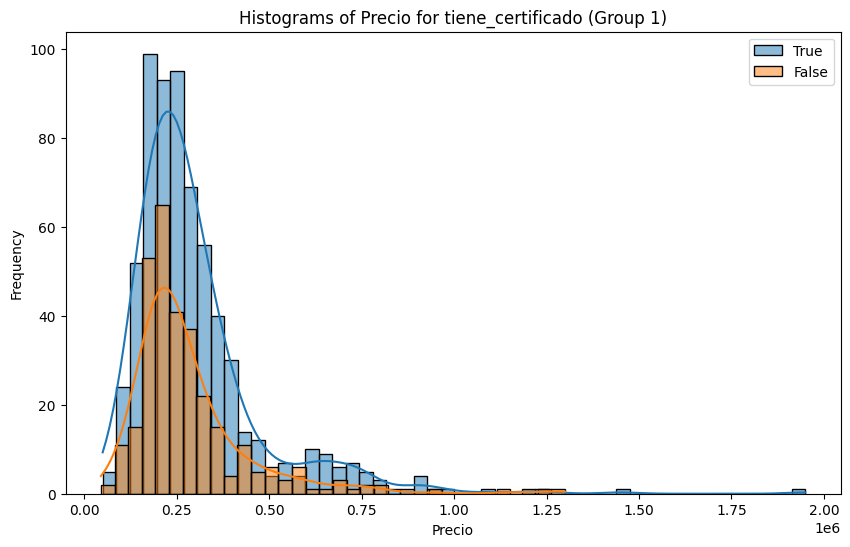

In [72]:
for col in (categoricas + binaria):
    if col in train_set.columns:
        bt.plot_grouped_histograms(train_set, cat_col=col, num_col='Precio', group_size = 8 )
    else:
        print(f'[WARN] {col} no está en df_plot.columns')

En esta parte se comparó el **precio** contra variables **categóricas, ordinales y binarias** para hacer una primera selección visual de *features*. La idea es simple: cuando las distribuciones de precio entre categorías **se separan o se cruzan** (es decir, no quedan todas iguales), suele ser una señal de que esa variable **podría aportar información** al modelo. En cambio, si las curvas/histogramas quedan muy parecidos entre sí, a simple vista esa variable parece menos discriminante (aunque siempre se confirma en validación). También es importante notar que, en varias variables, una categoría tiene mucha más cantidad de casos que las demás y “tapa” al resto, por lo que algunas conclusiones se toman con cautela.

En las variables más estructurales la señal fue la más consistente. **Baños** muestra un desplazamiento claro hacia precios más altos a medida que aumenta la cantidad (especialmente de 1 a 2). **Dormitorios** tiene bastante solapamiento entre 1–3, pero **4 dormitorios** aparece más corrido a la derecha, lo que sugiere impacto en el precio (posiblemente también mediado por superficie). Estas variables, por lo tanto, se consideran **de alto interés** para el modelo.

En confort/instalaciones, la evidencia es más suave. En **calefacción** se insinúa un gradiente (sin calefacción más a la izquierda y el resto algo más a la derecha), por lo que se mantiene como **feature potencialmente útil**. En **aire acondicionado**, en cambio, las categorías se superponen mucho y no se ve una separación marcada, por lo que queda como **feature de interés moderado** (se deja para que el modelo decida si aporta o no).

En variables de entorno (POIs), la interpretación es más compleja porque pueden estar capturando **zona/centralidad** y, además, muchas están dominadas por el valor máximo (por ejemplo, “5”), lo que hace que una categoría concentre la mayor parte de los anuncios y opaque diferencias. Aun así, aparecen señales que vale la pena conservar: en **transporte público**, el grupo con **0** se desplaza hacia precios más bajos, sugiriendo que la accesibilidad podría influir. En **hospitales** hay cruce y mezcla, pero los valores altos tienden a correrse hacia la derecha, lo que también podría estar capturando centralidad. En el resto (escuelas, farmacias, supermercados, tiendas, restaurantes y bares) hay bastante solapamiento y/o dominancia de una categoría, por lo que se mantienen como **candidatas** y se confirmará su aporte real luego.

Para las ordinales, **`categoria_ord`** muestra que los valores más altos concentran outliers y se mueven en rangos de precio superiores, por lo que se considera una variable **de interés**. En **`clase_energetica_ord`** se observa mucho solapamiento entre clases, sin una separación limpia, por lo que se clasifica como **de interés moderado**.

En las binarias, **ascensor** deja una señal leve hacia precios más altos y se mantiene como **feature relevante**. En cambio, variables como **planos**, **realista** y las banderas específicas de **tipo de calefacción (gas/eléctrica)** no muestran diferencias claras en esta inspección visual, por lo que quedan como **candidatas a simplificación** si no aportan mejora en el rendimiento del modelo.

Finalmente, también se exploró el comportamiento del precio por **clusters geográficos** (K-Means). En estos gráficos se observa que los grupos no comparten exactamente la misma distribución de precios, lo cual respalda la idea de que el cluster funciona como un proxy de “zona” y puede aportar señal adicional al modelo supervisado.

### Target contra variables **numéricas**

In [73]:
numericas_con_precio = numericas + ['Precio']

print('Correlacion de pearson:')
corr = train_set[numericas_con_precio].corr('pearson')
np.abs(corr[target]).sort_values(ascending = False)

Correlacion de pearson:


Precio                   1.000000
latitud                  0.236850
fotografias              0.208418
hosp_min_dist_m          0.184861
resto_min_dist_m         0.134090
emisiones_energeticas    0.131637
planta                   0.130269
tp_min_dist_m            0.129626
bar_min_dist_m           0.120906
tda_min_dist_m           0.114536
super_min_dist_m         0.109770
fca_min_dist_m           0.106844
eficiencia_energetica    0.073144
esc_min_dist_m           0.071121
ano_construccion         0.063735
superficie_m2            0.040431
longitud                 0.034027
Name: Precio, dtype: float64

In [24]:
print('Correlacion de spearman:')
corr_spe = train_set[numericas_con_precio].corr('spearman')
np.abs(corr_spe[target]).sort_values(ascending = False)

Correlacion de spearman:


Precio                   1.000000
superficie_m2            0.390307
latitud                  0.350087
resto_min_dist_m         0.262916
emisiones_energeticas    0.210247
fca_min_dist_m           0.205821
tda_min_dist_m           0.197787
tp_min_dist_m            0.193888
fotografias              0.193004
hosp_min_dist_m          0.190643
bar_min_dist_m           0.155367
super_min_dist_m         0.152460
planta                   0.151243
eficiencia_energetica    0.118471
esc_min_dist_m           0.115404
longitud                 0.068462
ano_construccion         0.024694
Name: Precio, dtype: float64

Para tener una primera medida cuantitativa de la relación entre el **precio** y las variables numéricas, se calcularon correlaciones con dos enfoques: **Pearson** y **Spearman**. Ambas ayudan a orientar qué variables podrían tener más señal, pero no deben interpretarse como “importancia” definitiva, especialmente en un problema inmobiliario donde suele haber **no linealidades**, **interacciones** (zona × superficie, etc.) y **outliers**.

En **Pearson** (relación lineal), las correlaciones observadas son en general **bajas a moderadas**. Esto es esperable porque el precio rara vez responde de forma lineal simple a cada variable por separado: el efecto suele depender del contexto (por ejemplo, una misma superficie puede valer distinto según la zona), y además la distribución del target es asimétrica con valores extremos, lo que puede afectar la estabilidad de la correlación lineal. Aun así, aparecen algunas señales que destacan dentro de este marco, como `latitud` y `fotografias`, y algunas distancias a POIs (por ejemplo `hosp_min_dist_m` y `resto_min_dist_m`), aunque con magnitudes limitadas.

Para complementar, se calculó **Spearman** (correlación por rangos), que captura mejor relaciones **monótonas** aunque no sean lineales y suele ser más robusta ante outliers. En este caso, Spearman muestra una asociación más clara de `superficie_m2` con `Precio`, y también mantienen cierta señal algunas variables de distancias/entorno y variables energéticas. La diferencia entre Pearson y Spearman sugiere que varias relaciones pueden ser no lineales o estar afectadas por la mezcla de zonas y por la cola derecha del precio.

En resumen, estas correlaciones se usan como un primer filtro orientativo: indican qué variables merecen atención, pero la contribución real se confirmará en el modelado (especialmente con algoritmos de árboles/boosting), que pueden capturar relaciones no lineales e interacciones que las correlaciones bivariantes no reflejan.

### **Matriz de correlacion**

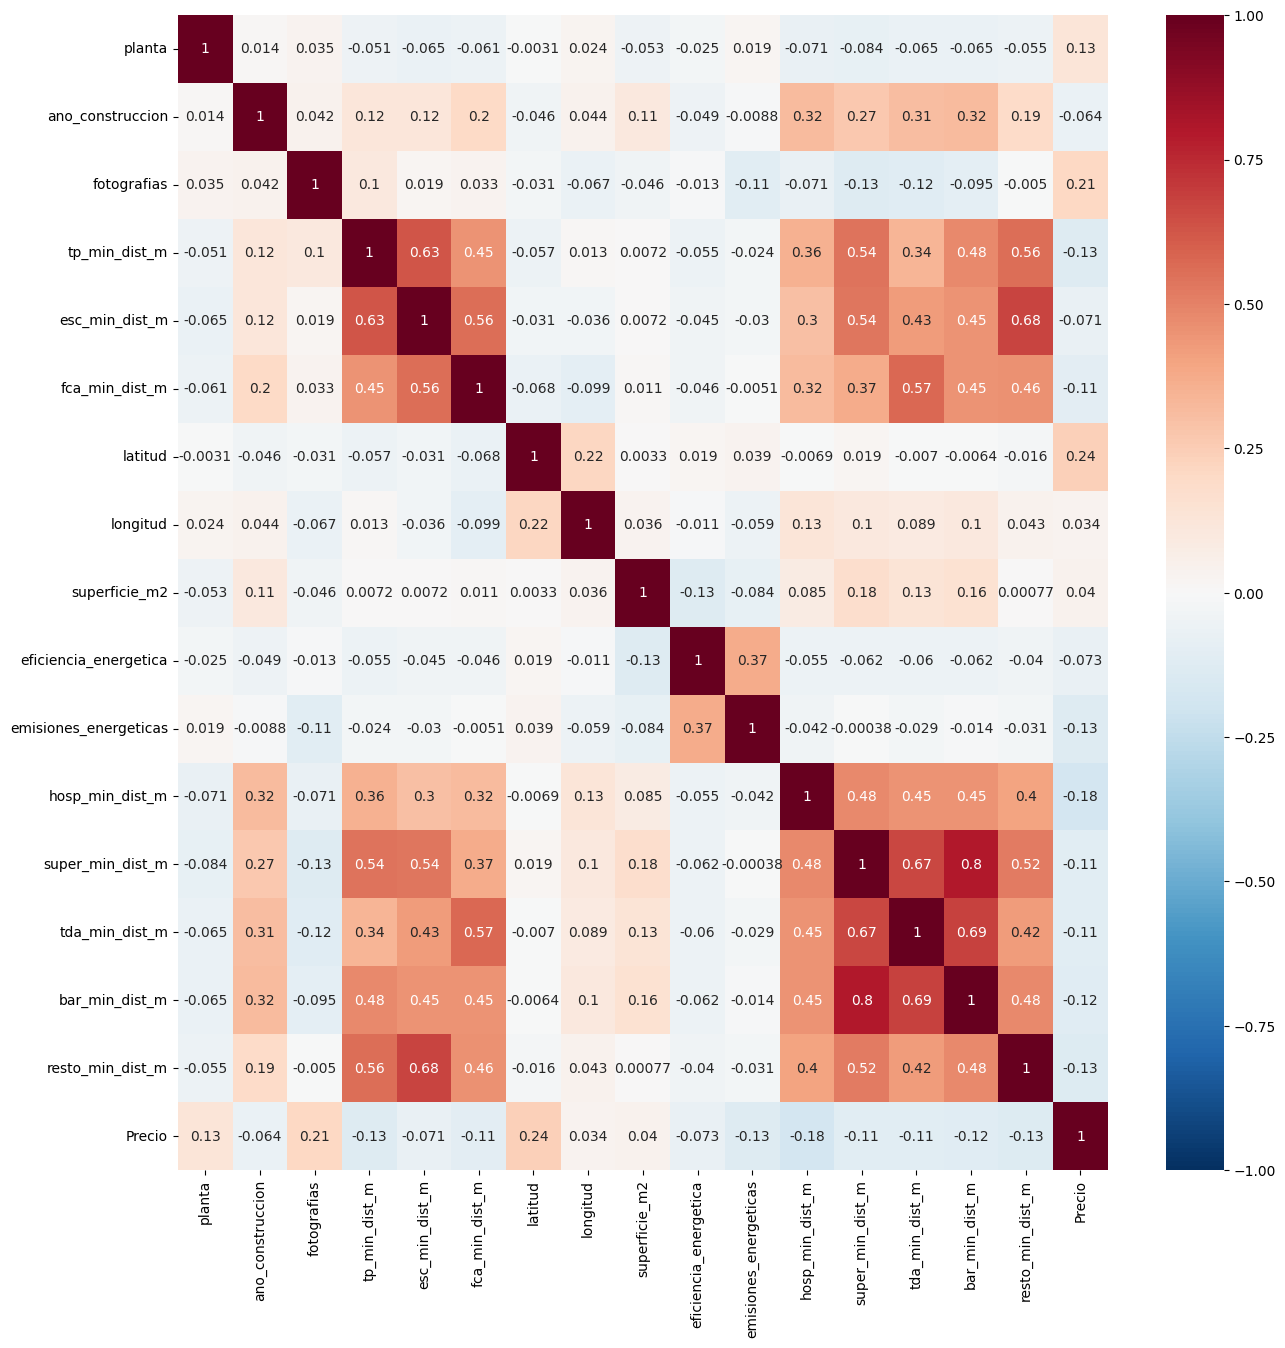

In [89]:
plt.figure(figsize = (15,15))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.show()

Luego de revisar la correlación del target con cada variable por separado, se calculó la **matriz de correlación** entre las variables numéricas para entender **cómo se relacionan entre sí**. El objetivo principal de este paso no es “explicar el precio”, sino detectar **colinealidad**: variables que aportan información muy parecida porque están fuertemente correlacionadas entre ellas. Esto es útil para decidir si conviene eliminar alguna, agruparlas o, al menos, tener presente que están midiendo un fenómeno similar.

En la matriz se observa que las correlaciones más altas aparecen principalmente entre las variables de **distancias mínimas a puntos de interés**, lo cual es esperable: zonas con alta densidad de servicios tienden a tener varios POIs cercanos al mismo tiempo. Por ejemplo, se ve una correlación alta (alrededor de **0.8**) entre `super_min_dist_m` y `bar_min_dist_m` (y patrones similares entre otras distancias), lo que sugiere que estas variables capturan en parte un mismo factor de “centralidad/entorno”.

En esta etapa **no se descarta ninguna variable** únicamente por correlación, ya que modelos basados en árboles/boosting suelen tolerar colinealidad mejor que modelos lineales y preferimos confirmar el aporte real de cada feature en el modelo. Sin embargo, esta matriz queda como referencia para interpretar resultados del modelo y para futuras simplificaciones del set de variables si se detecta redundancia sin ganancia predictiva.

#### **Si aplicamos logaritmo al target**

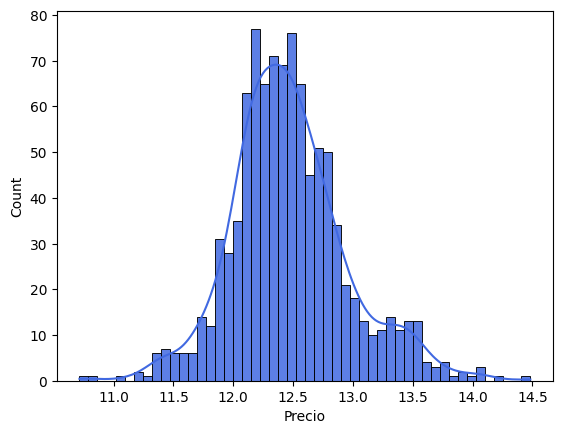

In [100]:
sns.histplot(np.log(train_set['Precio']), bins=50, kde=True, color='royalblue', alpha=0.85)
plt.show()

In [97]:
train_set['Precio_log'] = np.log(train_set['Precio'])
numericas_con_precio_log = numericas + ['Precio_log']

print('Correlacion de pearson con logaritmo:')
corr = train_set[numericas_con_precio_log].corr('pearson')
np.abs(corr['Precio_log']).sort_values(ascending = False)

Correlacion de pearson con logaritmo:


Precio_log               1.000000
latitud                  0.309181
hosp_min_dist_m          0.239813
tp_min_dist_m            0.226473
resto_min_dist_m         0.193737
fotografias              0.184137
planta                   0.177755
fca_min_dist_m           0.151147
bar_min_dist_m           0.148178
super_min_dist_m         0.147697
esc_min_dist_m           0.128050
tda_min_dist_m           0.127260
emisiones_energeticas    0.122830
longitud                 0.090261
eficiencia_energetica    0.061423
superficie_m2            0.038350
ano_construccion         0.033219
Name: Precio_log, dtype: float64

In [27]:
print('Correlacion de spearman con logaritmo:')
corr_spe = train_set[numericas_con_precio_log].corr('spearman')
np.abs(corr_spe['Precio_log']).sort_values(ascending = False)

Correlacion de spearman con logaritmo:


Precio_log               1.000000
superficie_m2            0.390307
latitud                  0.350087
resto_min_dist_m         0.262916
emisiones_energeticas    0.210247
fca_min_dist_m           0.205821
tda_min_dist_m           0.197787
tp_min_dist_m            0.193888
fotografias              0.193004
hosp_min_dist_m          0.190643
bar_min_dist_m           0.155367
super_min_dist_m         0.152460
planta                   0.151243
eficiencia_energetica    0.118471
esc_min_dist_m           0.115404
longitud                 0.068462
ano_construccion         0.024694
Name: Precio_log, dtype: float64

Como el `Precio` original tiene una cola derecha muy marcada y outliers, probamos aplicar un logaritmo al target (`Precio_log`) para ver si la distribución se vuelve más estable y si aparecen relaciones más claras con las variables numéricas. 

Al graficar `Precio_log`, la distribución queda mucho más “simétrica” y se reduce el efecto de los valores extremos. Al recalcular correlaciones, **Pearson tiende a subir** en varias variables, lo que sugiere que parte de la relación con el precio es más cercana a lineal cuando trabajamos en escala log (en otras palabras: cambios relativos de precio se explican mejor que cambios absolutos).

Un detalle que llama la atención es que, incluso usando `Precio_log`, `superficie_m2` no aparece como de las correlaciones más altas en Pearson, cuando intuitivamente debería influir. Esto suele pasar porque Pearson mide relación lineal “promedio” y acá hay mucha mezcla de zonas y de tipos de vivienda: un piso chico en una zona cara puede costar más que uno grande en una zona barata. El logaritmo ayuda a estabilizar la escala del precio, pero no elimina el efecto de la ubicación ni las interacciones (por ejemplo, superficie × zona/cluster), que pueden diluir una relación lineal simple.

Por eso, una correlación moderada no implica que la superficie no sea importante: en este tipo de problemas su aporte suele aparecer mejor cuando el modelo puede capturar no linealidades e interacciones, especialmente combinándola con variables de localización (lat/long o `cluster`).

Cuando miramos Spearman, la relación con `superficie_m2` tiende a verse más clara, lo que sugiere que la superficie sí aporta señal, pero no de forma lineal simple en euros.

# **Comparación inicial de modelos**  

Con el dataset ya preparado, se realizó una primera comparación de modelos para tener un **baseline** y elegir una familia de algoritmos para la etapa de ajuste fino. Para que la comparación sea justa y reproducible, se armó un flujo con `Pipeline` + `ColumnTransformer`, separando el tratamiento de variables numéricas y categóricas:

- **Numéricas:** imputación por mediana.  
- **Categóricas:** imputación por moda + `OneHotEncoder`.

Se implementaron **dos preprocesados**:
1) Un preprocesado **sin escalado**, pensado para modelos basados en árboles/boosting (no requieren estandarización).
2) Un preprocesado **con escalado** (`StandardScaler`), necesario para modelos sensibles a la escala como **KNN** y **regresión lineal**.

Además, para estabilizar el entrenamiento frente al sesgo del target, se evaluaron los modelos usando una transformación del target (log) mediante `TransformedTargetRegressor`, manteniendo la comparación consistente entre algoritmos.

Los modelos comparados fueron:
- **Árboles y ensembles:** `DecisionTreeRegressor`, `RandomForestRegressor`
- **Boosting:** `XGBRegressor`, `LGBMRegressor`, `CatBoostRegressor`
- **Modelos basados en distancia / lineales (con escalado):** `KNeighborsRegressor` (k=3 y k=5) y `LinearRegression`

Dado lo observado en el EDA (relaciones no lineales, interacción entre variables y presencia de outliers), se espera que los modelos de **árboles/boosting** tengan mejor desempeño que un enfoque estrictamente lineal. Aun así, se incluyen modelos lineales y KNN como referencia comparativa.

#### **Métrica de evaluación: MAPE**

Para comparar modelos se utilizó **MAPE** (*Mean Absolute Percentage Error*). Elegimos esta métrica porque mide el error en **términos relativos** (porcentaje), lo que resulta más apropiado en precios inmobiliarios donde el target tiene **cola derecha y outliers**: un error absoluto grande en euros puede ser esperable en viviendas muy caras, pero no necesariamente representa el mismo “nivel de fallo” que ese mismo error en una vivienda media. 

En otras palabras, MAPE penaliza el error de manera proporcional al valor real del inmueble, lo que hace la comparación más estable cuando hay anuncios de precios muy altos. Por eso es una métrica útil para tener una primera foto del desempeño de los modelos en un dataset con alta dispersión y valores extremos.

In [101]:
num_sel = make_column_selector(dtype_include = np.number)
cat_sel = make_column_selector(dtype_include = object)

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
            ]), num_sel),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_sel),
    ],
    remainder='drop',
).set_output(transform='pandas')

preprocess_scale = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_sel),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_sel),

    ],
    remainder='drop'
).set_output(transform='pandas')

preprocess.fit_transform(X_train_limpio).head()

,num__latitud,num__longitud,num__dormitorios,num__superficie_m2,num__baños,num__planta,num__ascensor,num__ano_construccion,num__planos,num__fotografias,num__eficiencia_energetica,num__emisiones_energeticas,num__tp_cnt,num__tp_min_dist_m,num__esc_cnt,num__esc_min_dist_m,num__fca_cnt,num__fca_min_dist_m,num__hosp_cnt,num__hosp_min_dist_m,num__super_cnt,num__super_min_dist_m,num__tda_cnt,num__tda_min_dist_m,num__bar_cnt,num__bar_min_dist_m,num__resto_cnt,num__resto_min_dist_m,num__calefaccion_gas,num__calefaccion_electrica,num__categoria_ord,num__clase_energetica_ord,cat__cluster_A,cat__cluster_B,cat__cluster_C,cat__cluster_D,cat__cluster_E,cat__cluster_F,cat__aire_acondicionado_Centralizada,cat__aire_acondicionado_Independiente,cat__aire_acondicionado_None,cat__calefaccion_Independiente,cat__calefaccion_None,cat__calefaccion_centralizada
1055,40.489602,-3.886053,2.0,120.0,1.0,3.0,1.0,1990.0,1.0,29.0,240.6,50.4,3.0,140.0,5.0,320.0,5.0,770.0,1.0,2100.0,5.0,720.0,5.0,710.0,5.0,180.0,5.0,610.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
666,40.446802,-3.703233,2.0,42.0,1.0,2.0,0.0,1925.0,0.0,22.0,162.0,34.0,5.0,60.0,5.0,150.0,5.0,50.0,5.0,380.0,5.0,110.0,5.0,40.0,5.0,100.0,5.0,50.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1014,40.494502,-3.693703,4.0,88.0,2.0,5.0,1.0,1979.0,0.0,24.0,294.0,61.0,5.0,40.0,5.0,60.0,5.0,70.0,5.0,890.0,5.0,220.0,5.0,340.0,5.0,330.0,5.0,310.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
650,40.484702,-3.359223,2.0,80.0,1.0,0.0,0.0,1965.0,0.0,24.0,222.0,49.7,4.0,90.0,5.0,60.0,5.0,150.0,5.0,740.0,5.0,170.0,5.0,90.0,5.0,150.0,5.0,150.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
899,40.435002,-3.706983,5.0,152.0,2.0,5.0,0.0,1940.0,0.0,29.0,174.0,36.0,5.0,130.0,5.0,110.0,5.0,100.0,5.0,400.0,5.0,40.0,5.0,190.0,5.0,100.0,5.0,30.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [102]:
models = {
    'DecisionTree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'RandomForest': RandomForestRegressor(max_depth=5, random_state=42),
    'XGBRegressor': XGBRegressor(max_depth=5, random_state=42, objective='reg:absoluteerror',),
    'LGBMRegressor': LGBMRegressor(max_depth=5, random_state=42, verbosity=-1),
    'CatBoostRegressor': CatBoostRegressor(depth=5, random_state=42, loss_function='MAPE', verbose=False, train_dir='catboost_tmp'),
}


results = []

for name, model in models.items():
    print(f'Entrenando {name}...')
    pipe = Pipeline(steps=[('preprocess', preprocess), ('model', model)])

    pipe_log = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

    scores = cross_val_score(pipe_log, X_train_limpio, y_train, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1,)
    mape_scores = -scores                 
     
    results.append({
        'model': name,
        'mean_MAPE': mape_scores.mean(),
    })

Entrenando DecisionTree...
Entrenando RandomForest...
Entrenando XGBRegressor...
Entrenando LGBMRegressor...
Entrenando CatBoostRegressor...


In [103]:
models_scale = {
    'lr_reg' : LinearRegression(),
    'knn_reg_3' : KNeighborsRegressor(n_neighbors= 3),
    'knn_reg_5' : KNeighborsRegressor(n_neighbors= 5),
}


for name, model in models_scale.items():
    print(f'Entrenando {name}...')
    pipe = Pipeline(steps=[('preprocess', preprocess_scale), ('model', model)])

    pipe_log = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

    scores_scale = cross_val_score(pipe_log, X_train_limpio, y_train, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1,)
    mape_scores = -scores_scale                
     
    results.append({
        'model': name,
        'mean_MAPE': mape_scores.mean(),
    })

results_df = pd.DataFrame(results).sort_values('mean_MAPE')
results_df

Entrenando lr_reg...
Entrenando knn_reg_3...
Entrenando knn_reg_5...


,model,mean_MAPE
3,LGBMRegressor,1.663109e-01
4,CatBoostRegressor,1.673792e-01
2,XGBRegressor,1.841956e-01
1,RandomForest,1.968118e-01
0,DecisionTree,2.456673e-01
7,knn_reg_5,2.570396e-01
6,knn_reg_3,2.657768e-01
5,lr_reg,7.876955e+14


En esta primera corrida, los modelos con mejor desempeño fueron los de **boosting**, destacándose de forma consistente **LightGBM**, **CatBoost** y **XGBoost** como el top 3. En un segundo escalón quedaron **RandomForest** y **DecisionTree**, mientras que **KNN** rindió peor que los boosting. La **regresión lineal** no resultó competitiva en este problema, lo cual es coherente con lo observado en el EDA: hay no linealidades, interacción entre variables y efectos de zona que un modelo lineal no captura bien.

Ahora bien, si analizamos el valor de MAPE obtenido en esta corrida, un valor cercano a **0.166** se interpreta, en promedio, como un error de alrededor de **16.6%** respecto del precio real.

Llevándolo a euros para tener una referencia práctica:
- Si la vivienda vale **250.000 €**, un 16.6% equivale a ~**41.500 €**.
- Si vale **338.000 €** (rango donde se concentra gran parte del dataset), un 16.6% equivale a ~**56.100 €**.

Esto ayuda a contextualizar la métrica: aunque el dataset tenga un máximo cercano a **1.950.000 €**, MAPE pondera el error de manera relativa, por lo que el rendimiento queda más alineado con el “precio típico” del conjunto (donde se concentra la mayoría de anuncios). Por eso MAPE es una métrica útil en este contexto: evita que unos pocos outliers muy caros dominen completamente la evaluación, como suele ocurrir con métricas en unidades absolutas (euros).

### **Ajuste de hiperparametros**

Una vez identificados los modelos con mejor desempeño en la comparación inicial, pasamos a una etapa de **ajuste de hiperparámetros** para intentar mejorar el rendimiento. Para esto se utiliza **Optuna**, que permite explorar de forma automática y eficiente distintas combinaciones de parámetros y seleccionar las que optimizan la métrica elegida.

En esta sección se ajustarán los tres modelos top: **XGBoost**, **LightGBM** y **CatBoost**, manteniendo el mismo esquema de validación y la misma métrica (MAPE) para que los resultados sean comparables.

In [104]:
def objective_xgb(trial):
    
    xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
    pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])

    params = {
        'model__n_estimators': trial.suggest_int('model__n_estimators', 500, 1200),
        'model__learning_rate': trial.suggest_float('model__learning_rate', 0.01, 0.15, log=True),
        'model__max_depth': trial.suggest_int('model__max_depth', 4, 8),
        'model__min_child_weight': trial.suggest_int('model__min_child_weight', 1, 5),
        'model__subsample': trial.suggest_float('model__subsample', 0.7, 1.0),
        'model__colsample_bytree': trial.suggest_float('model__colsample_bytree', 0.7, 1.0),
        'model__reg_alpha': trial.suggest_float('model__reg_alpha', 1e-3, 1.0, log=True),
        'model__reg_lambda': trial.suggest_float('model__reg_lambda', 1.0, 5.0),
    }
    
    pipe_xgb.set_params(**params)
    
    pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)
    
    score = cross_val_score(
        pipe_xgb_log,
        X_train_limpio,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1
    ).mean()
    
    return score

study_xgb = create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100)

best_params_xgb = study_xgb.best_params
best_params_xgb

[I 2026-03-02 21:12:26,164] A new study created in memory with name: no-name-63b92a64-858b-4104-b67b-25c082e34073
[I 2026-03-02 21:12:29,626] Trial 0 finished with value: -0.16692651223117702 and parameters: {'model__n_estimators': 663, 'model__learning_rate': 0.017653623840391344, 'model__max_depth': 7, 'model__min_child_weight': 5, 'model__subsample': 0.9359496899922418, 'model__colsample_bytree': 0.7076708889963571, 'model__reg_alpha': 0.00844949588079649, 'model__reg_lambda': 2.632714092612762}. Best is trial 0 with value: -0.16692651223117702.
[I 2026-03-02 21:12:32,469] Trial 1 finished with value: -0.16641203752013461 and parameters: {'model__n_estimators': 925, 'model__learning_rate': 0.0755846782397138, 'model__max_depth': 8, 'model__min_child_weight': 3, 'model__subsample': 0.7478350515077647, 'model__colsample_bytree': 0.9783140374004293, 'model__reg_alpha': 0.0020452917219237646, 'model__reg_lambda': 4.848055215092279}. Best is trial 1 with value: -0.16641203752013461.
[I 2

{'model__n_estimators': 1142,
 'model__learning_rate': 0.05241516366732835,
 'model__max_depth': 5,
 'model__min_child_weight': 4,
 'model__subsample': 0.8543869587657864,
 'model__colsample_bytree': 0.9962150715787833,
 'model__reg_alpha': 0.007993281525643374,
 'model__reg_lambda': 4.215610871972271}

In [130]:
xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_xgb = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', xgb_base)])

pipe_xgb.set_params(**best_params_xgb)

pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

pipe_xgb_log.fit(X_train, y_train)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('features',
                                                      Pipeline(steps=[('aplanar_campos',
                                                                       FunctionTransformer(func=<function aplanar_campos_anidados at 0x0000017077BA6FC0>)),
                                                                      ('poi_features',
                                                                       FunctionTransformer(func=<function crear_features_poi at 0x0000017077BA7060>)),
                                                                      ('final_clean',
                                                                       FunctionTransfo...
                                                                   gamma=None,
                                                                   grow_policy=None,
                                                                   importance_type=None,
                                                                   interaction_constraints=None,
                                                                   learning_rate=0.05241516366732835,
                                                                   max_bin=None,
                                                                   max_cat_threshold=None,
                                                                   max_cat_to_onehot=None,
                                                                   max_delta_step=None,
                                                                   max_depth=5,
                                                                   max_leaves=None,
                                                                   min_child_weight=4,
                                                                   missing=nan,
                                                                   monotone_constraints=None,
                                                                   multi_strategy=None,
                                                                   n_estimators=1142,
                                                                   n_jobs=-1,
                                                                   num_parallel_tree=None, ...))]))

In [131]:
print(f' MAPE XGBoost: {mean_absolute_percentage_error(y_test, pipe_xgb_log.predict(X_test))}')

 MAPE XGBoost: 0.15555491777434777


c:\Users\Usuario\Desktop\data_science\Bootcamp_TheBridge\ML_Prediccion_Precio_Vivienda_Madrid\src\cajon_basura\utils.py:265: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


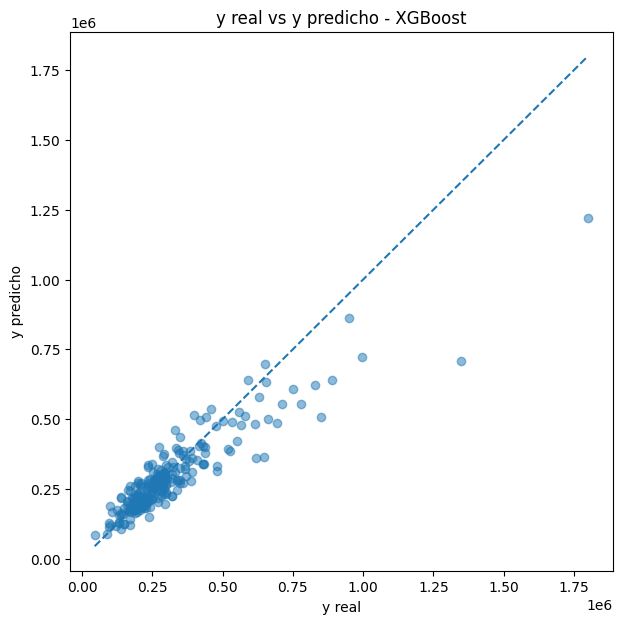

In [118]:
y_pred_xgb = pipe_xgb_log.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)
min_v = min(np.min(y_test), np.min(y_pred_xgb))
max_v = max(np.max(y_test), np.max(y_pred_xgb))
plt.plot([min_v, max_v], [min_v, max_v], linestyle='--')  # línea y=x (predicción perfecta)
plt.xlabel('y real')
plt.ylabel('y predicho')
plt.title('y real vs y predicho - XGBoost')
plt.show()

XGBoost: 0.1475 -> 1m42s

In [107]:
def objective_lgb(trial):
    
    lgb_base = LGBMRegressor(random_state=42, n_jobs=-1, objective='regression', verbosity=-1)
    pipe_lgb = Pipeline(steps=[('preprocess', preprocess), ('model', lgb_base)])
    
    params = {
        'model__n_estimators': trial.suggest_int('model__n_estimators', 500, 1200),
        'model__learning_rate': trial.suggest_float('model__learning_rate', 0.01, 0.15, log=True),
        'model__max_depth': trial.suggest_int('model__max_depth', 4, 12),
        'model__num_leaves': trial.suggest_int('model__num_leaves', 20, 100),
        'model__min_child_samples': trial.suggest_int('model__min_child_samples', 5, 50),
        'model__subsample': trial.suggest_float('model__subsample', 0.7, 1.0),
        'model__colsample_bytree': trial.suggest_float('model__colsample_bytree', 0.7, 1.0),
        'model__reg_alpha': trial.suggest_float('model__reg_alpha', 1e-3, 1.0, log=True),
        'model__reg_lambda': trial.suggest_float('model__reg_lambda', 1.0, 5.0),
    }
    
    pipe_lgb.set_params(**params)
    
    pipe_lgb_log = TransformedTargetRegressor(regressor=pipe_lgb, func=np.log1p, inverse_func=np.expm1)
    
    score = cross_val_score(
        pipe_lgb_log,
        X_train_limpio,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1
    ).mean()
    
    return score

study_lgb = create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=100)

best_params_lgb = study_lgb.best_params
best_params_lgb

[I 2026-03-02 21:15:49,694] A new study created in memory with name: no-name-99f1c074-df96-4c48-a56b-12ed660e203e


[I 2026-03-02 21:15:50,811] Trial 0 finished with value: -0.18028433052274218 and parameters: {'model__n_estimators': 586, 'model__learning_rate': 0.0585509077170394, 'model__max_depth': 4, 'model__num_leaves': 30, 'model__min_child_samples': 49, 'model__subsample': 0.8917330468660686, 'model__colsample_bytree': 0.8428904357631646, 'model__reg_alpha': 0.020201973193839096, 'model__reg_lambda': 3.7475007930370463}. Best is trial 0 with value: -0.18028433052274218.
[I 2026-03-02 21:15:52,437] Trial 1 finished with value: -0.16915006977923447 and parameters: {'model__n_estimators': 749, 'model__learning_rate': 0.013682888937918957, 'model__max_depth': 5, 'model__num_leaves': 65, 'model__min_child_samples': 36, 'model__subsample': 0.8166087056689586, 'model__colsample_bytree': 0.8265374337195827, 'model__reg_alpha': 0.043492076229300555, 'model__reg_lambda': 3.676292556086635}. Best is trial 1 with value: -0.16915006977923447.
[I 2026-03-02 21:15:55,214] Trial 2 finished with value: -0.164

{'model__n_estimators': 1041,
 'model__learning_rate': 0.016083744295425206,
 'model__max_depth': 6,
 'model__num_leaves': 48,
 'model__min_child_samples': 11,
 'model__subsample': 0.8531617872372843,
 'model__colsample_bytree': 0.7188862294822586,
 'model__reg_alpha': 0.012934514394030603,
 'model__reg_lambda': 4.348429080096658}

In [109]:
lgb_base = LGBMRegressor(random_state=42, n_jobs=-1, objective='regression', verbosity=-1)
pipe_lgb = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', lgb_base)])

pipe_lgb.set_params(**best_params_lgb)

pipe_lgb_log = TransformedTargetRegressor(regressor=pipe_lgb, func=np.log1p, inverse_func=np.expm1)

pipe_lgb_log.fit(X_train, y_train)

c:\Users\Usuario\Desktop\data_science\Bootcamp_TheBridge\ML_Prediccion_Precio_Vivienda_Madrid\src\cajon_basura\utils.py:265: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('features',
                                                      Pipeline(steps=[('aplanar_campos',
                                                                       FunctionTransformer(func=<function aplanar_campos_anidados at 0x0000017077BA6FC0>)),
                                                                      ('poi_features',
                                                                       FunctionTransformer(func=<function crear_features_poi at 0x0000017077BA7060>)),
                                                                      ('final_clean',
                                                                       FunctionTransfo...
                                                                                       <sklearn.compose._column_transformer.make_column_selector object at 0x000001701224AF00>)])),
                                                     ('model',
                                                      LGBMRegressor(colsample_bytree=0.7188862294822586,
                                                                    learning_rate=0.016083744295425206,
                                                                    max_depth=6,
                                                                    min_child_samples=11,
                                                                    n_estimators=1041,
                                                                    n_jobs=-1,
                                                                    num_leaves=48,
                                                                    objective='regression',
                                                                    random_state=42,
                                                                    reg_alpha=0.012934514394030603,
                                                                    reg_lambda=4.348429080096658,
                                                                    subsample=0.8531617872372843,
                                                                    verbosity=-1))]))

In [128]:
print(f' MAPE LGBoost: {mean_absolute_percentage_error(y_test, pipe_lgb_log.predict(X_test))}')

 MAPE LGBoost: 0.16367980511635208


LightGBoost: 0.1549 -> 4m09s

c:\Users\Usuario\Desktop\data_science\Bootcamp_TheBridge\ML_Prediccion_Precio_Vivienda_Madrid\src\cajon_basura\utils.py:265: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


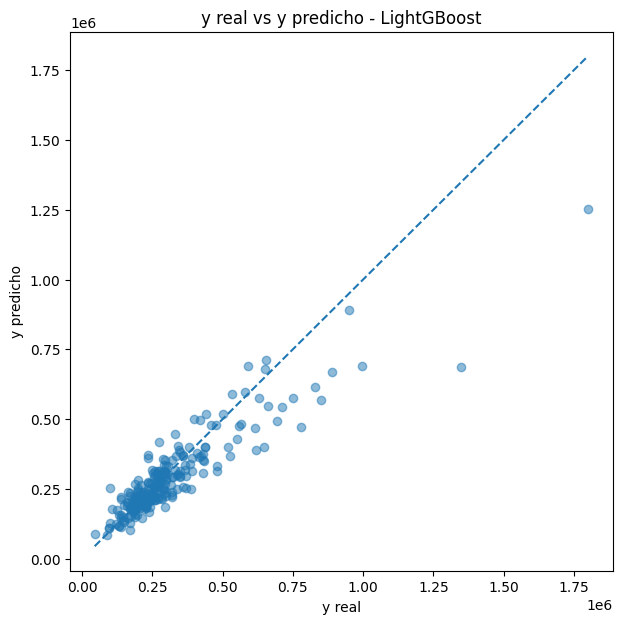

In [119]:
y_pred_lgb = pipe_lgb_log.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_lgb, alpha=0.5)
min_v = min(np.min(y_test), np.min(y_pred_lgb))
max_v = max(np.max(y_test), np.max(y_pred_lgb))
plt.plot([min_v, max_v], [min_v, max_v], linestyle='--')  # línea y=x (predicción perfecta)
plt.xlabel('y real')
plt.ylabel('y predicho')
plt.title('y real vs y predicho - LightGBoost')
plt.show()

In [112]:
def objective_cat(trial):

    cat_base = CatBoostRegressor(random_state=42, loss_function="MAPE",verbose=False,)
    pipe_cat = Pipeline(steps=[('preprocess', preprocess), ("model", cat_base)])

    params = {
        "model__depth": trial.suggest_int("model__depth", 6, 10),
        "model__learning_rate": trial.suggest_float("model__learning_rate", 0.01, 0.15, log=True),
        "model__iterations": trial.suggest_int("model__iterations", 500, 1200),
        "model__l2_leaf_reg": trial.suggest_float("model__l2_leaf_reg", 1.0, 10.0),
        "model__subsample": trial.suggest_float("model__subsample", 0.7, 1.0),
        "model__random_strength": trial.suggest_float("model__random_strength", 0.5, 2.0),
    }
    
    pipe_cat.set_params(**params)

    pipe_cat_log = TransformedTargetRegressor(regressor=pipe_cat, func=np.log1p, inverse_func=np.expm1)
    
    score = cross_val_score(
        pipe_cat_log,
        X_train_limpio,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_percentage_error",
        n_jobs=-1
    ).mean()
    
    return score

study_cat = create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=100)

best_params_cat = study_cat.best_params
best_params_cat

[I 2026-03-02 21:26:57,081] A new study created in memory with name: no-name-eae820e4-c08f-4b36-8ac8-b6ee58db0391
[I 2026-03-02 21:27:20,377] Trial 0 finished with value: -0.19572164754277735 and parameters: {'model__depth': 10, 'model__learning_rate': 0.0653526459073242, 'model__iterations': 756, 'model__l2_leaf_reg': 3.8927696285174505, 'model__subsample': 0.7532253064893807, 'model__random_strength': 1.8675617227230736}. Best is trial 0 with value: -0.19572164754277735.
[I 2026-03-02 21:27:34,625] Trial 1 finished with value: -0.18621314326638622 and parameters: {'model__depth': 9, 'model__learning_rate': 0.06652309475425452, 'model__iterations': 1045, 'model__l2_leaf_reg': 3.0637903542199227, 'model__subsample': 0.7202362660054759, 'model__random_strength': 1.9685762102986026}. Best is trial 1 with value: -0.18621314326638622.
[I 2026-03-02 21:27:39,461] Trial 2 finished with value: -0.17258818107652923 and parameters: {'model__depth': 7, 'model__learning_rate': 0.01605134589544286

{'model__depth': 6,
 'model__learning_rate': 0.03758128832306495,
 'model__iterations': 1085,
 'model__l2_leaf_reg': 7.232554040245198,
 'model__subsample': 0.9598213615626197,
 'model__random_strength': 0.9438022330625295}

In [113]:
cat_base = CatBoostRegressor(random_state=42, loss_function='MAPE', verbose=False)
pipe_cat = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', cat_base)])

pipe_cat.set_params(**best_params_cat)

pipe_cat_log = TransformedTargetRegressor(regressor=pipe_cat, func=np.log1p, inverse_func=np.expm1)

pipe_cat_log.fit(X_train, y_train)

c:\Users\Usuario\Desktop\data_science\Bootcamp_TheBridge\ML_Prediccion_Precio_Vivienda_Madrid\src\cajon_basura\utils.py:265: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('features',
                                                      Pipeline(steps=[('aplanar_campos',
                                                                       FunctionTransformer(func=<function aplanar_campos_anidados at 0x0000017077BA6FC0>)),
                                                                      ('poi_features',
                                                                       FunctionTransformer(func=<function crear_features_poi at 0x0000017077BA7060>)),
                                                                      ('final_clean',
                                                                       FunctionTransfo...
                                                                                       <sklearn.compose._column_transformer.make_column_selector object at 0x00000170121B9B80>),
                                                                                      ('cat',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('onehot',
                                                                                                        OneHotEncoder(handle_unknown='ignore',
                                                                                                                      sparse_output=False))]),
                                                                                       <sklearn.compose._column_transformer.make_column_selector object at 0x000001701224AF00>)])),
                                                     ('model',
                                                      <catboost.core.CatBoostRegressor object at 0x000001701480ECC0>)]))

In [132]:
print(f' MAPE CatBoost: {mean_absolute_percentage_error(y_test, pipe_cat_log.predict(X_test))}');

 MAPE CatBoost: 0.1599770972548418


CatBoost: 0.1594 -> 11m57s

c:\Users\Usuario\Desktop\data_science\Bootcamp_TheBridge\ML_Prediccion_Precio_Vivienda_Madrid\src\cajon_basura\utils.py:265: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


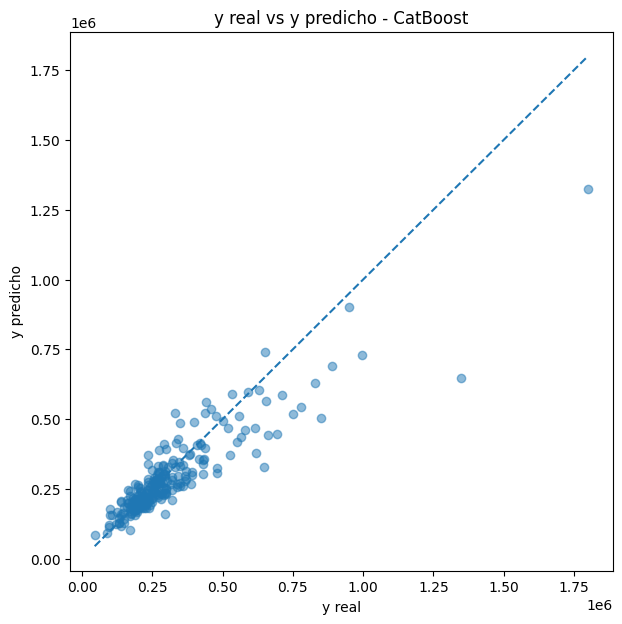

In [120]:
y_pred_cat = pipe_cat_log.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_cat, alpha=0.5)
min_v = min(np.min(y_test), np.min(y_pred_cat))
max_v = max(np.max(y_test), np.max(y_pred_cat))
plt.plot([min_v, max_v], [min_v, max_v], linestyle='--')  # línea y=x (predicción perfecta)
plt.xlabel('y real')
plt.ylabel('y predicho')
plt.title('y real vs y predicho - CatBoost')
plt.show()

### **Comparación final entre los 3 mejores modelos (error, gráfico y tiempo)**

Para decidir el modelo final, además del MAPE se revisó el gráfico **`y_real vs y_predicho`** y el **tiempo de entrenamiento/predicción** de cada alternativa (XGBoost, LightGBM y CatBoost). En los tres scatter plots, la mayoría de puntos se concentra cerca de la diagonal (predicción perfecta), pero se ve el patrón típico del problema: a medida que sube el precio real, aparece más dispersión y algunos outliers quedan subestimados o sobreestimados.

En términos de **error**, XGBoost fue el que obtuvo el mejor MAPE (menor valor), mientras que LightGBM y CatBoost quedaron ligeramente por encima. En cuanto a **comportamiento visual**, XGBoost muestra una nube de puntos más “apretada” alrededor de la diagonal en el rango donde se concentra la mayor parte del dataset, y las mayores discrepancias aparecen principalmente en los precios más altos (outliers), que es esperable dado el sesgo del target.

Finalmente, al considerar el **tiempo**, CatBoost resultó claramente el más lento, LightGBM quedó en un punto intermedio y XGBoost fue el más rápido de los tres en esta corrida. 

Con estos tres elementos en conjunto (**mejor MAPE + buena alineación visual + menor tiempo**), se elige **XGBoost** como modelo final para continuar con el ajuste de hiperparámetros y la evaluación definitiva. Primero haremos un estudio de rendimiento para obtener un modelo más ligero con una seleccion de features inteligente:

In [126]:
xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])

pipe_xgb.set_params(**best_params_xgb)

pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

start = time()
pipe_xgb_log.fit(X_train_limpio, y_train)
train_time = [(time() - start)]

score = [cross_val_score(pipe_xgb_log, X_train_limpio, y_train, cv=5, scoring="neg_mean_absolute_percentage_error", n_jobs=-1).mean()]

pd.DataFrame({'score': score, 'time': train_time}).sort_values('score')

,score,time
0,-0.16054,0.658358


In [160]:
def performar_tiempo(X, y, col=None):

    if col:
        X = X.drop(columns=col)

    lista_col = []
    train_time = []
    score = []

    xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
    pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])
    pipe_xgb.set_params(**best_params_xgb)
    pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

    for col in X.columns:

        print(f'Ocultando {col}...', end='\t')
        lista_col.append(col)
        X_menos = X.drop(columns=col)

        start = time()
        pipe_xgb_log.fit(X_menos, y)
        train_time.append(time() - start)

        score.append(cross_val_score(pipe_xgb_log, X_menos, y, cv=5, scoring="neg_mean_absolute_percentage_error", n_jobs=-1).mean())
    
    resultados = pd.DataFrame({'columna': lista_col, 'score': score, 'time': train_time}).set_index('columna').sort_values('score', ascending=False).iloc[0]

    if len(X.columns) > 2:
        print(f'Eliminamos {resultados.name}...')
        resultados = pd.concat([resultados, performar_tiempo(X, y, col=resultados.name)], axis=1)

    return resultados

resultados_funcion = performar_tiempo(X_train_limpio, y_train)
resultados_funcion

Ocultando dormitorios...	Ocultando superficie_m2...	Ocultando baños...	Ocultando latitud...	Ocultando longitud...	Ocultando planta...	Ocultando aire_acondicionado...	Ocultando ascensor...	Ocultando calefaccion...	Ocultando ano_construccion...	Ocultando planos...	Ocultando realista...	Ocultando fotografias...	Ocultando eficiencia_energetica...	Ocultando emisiones_energeticas...	Ocultando tp_cnt...	Ocultando tp_min_dist_m...	Ocultando esc_cnt...	Ocultando esc_min_dist_m...	Ocultando fca_cnt...	Ocultando fca_min_dist_m...	Ocultando hosp_cnt...	Ocultando hosp_min_dist_m...	Ocultando super_cnt...	Ocultando super_min_dist_m...	Ocultando tda_cnt...	Ocultando tda_min_dist_m...	Ocultando bar_cnt...	Ocultando bar_min_dist_m...	Ocultando resto_cnt...	Ocultando resto_min_dist_m...	Ocultando calefaccion_gas...	Ocultando calefaccion_electrica...	Ocultando categoria_ord...	Ocultando clase_energetica_ord...	Ocultando tiene_certificado...	Ocultando cluster...	Eliminamos emisiones_energeticas...
Ocultan

,emisiones_energeticas,tiene_certificado,realista,fotografias,resto_cnt,aire_acondicionado,tda_min_dist_m,tp_cnt,bar_cnt,super_min_dist_m,calefaccion_electrica,esc_min_dist_m,categoria_ord,hosp_cnt,resto_min_dist_m,planos,fca_cnt,super_cnt,cluster,eficiencia_energetica,fca_min_dist_m,calefaccion_gas,tda_cnt,esc_cnt,clase_energetica_ord,planta,ascensor,bar_min_dist_m,dormitorios,baños,calefaccion,tp_min_dist_m,ano_construccion,hosp_min_dist_m,longitud,superficie_m2
score,-0.162590,-0.16259,-0.162590,-0.163399,-0.162648,-0.162701,-0.162686,-0.160759,-0.162024,-0.162100,-0.159998,-0.159788,-0.159866,-0.161420,-0.159866,-0.161121,-0.159541,-0.160264,-0.161948,-0.161378,-0.160129,-0.160007,-0.159073,-0.161331,-0.161491,-0.161434,-0.163982,-0.162323,-0.165874,-0.167198,-0.169675,-0.172764,-0.176154,-0.183280,-0.276009,-0.329524
time,0.758061,0.75728,0.793649,0.757717,0.762101,0.810068,0.757261,0.720571,0.732436,0.710808,0.645652,0.643524,0.620321,0.711686,0.602540,0.667598,0.610801,0.653140,0.560028,0.548375,0.526364,0.674038,0.633265,0.579277,0.577263,0.560065,0.603598,0.528336,0.528584,0.544464,0.503287,0.431686,0.562927,0.487907,0.363766,0.348455


In [161]:
resultados_funcion.T.reset_index().reset_index()


,level_0,index,score,time
0,0,emisiones_energeticas,-0.162590,0.758061
1,1,tiene_certificado,-0.162590,0.757280
2,2,realista,-0.162590,0.793649
3,3,fotografias,-0.163399,0.757717
4,4,resto_cnt,-0.162648,0.762101
5,5,aire_acondicionado,-0.162701,0.810068
6,6,tda_min_dist_m,-0.162686,0.757261
7,7,tp_cnt,-0.160759,0.720571
8,8,bar_cnt,-0.162024,0.732436
9,9,super_min_dist_m,-0.162100,0.710808


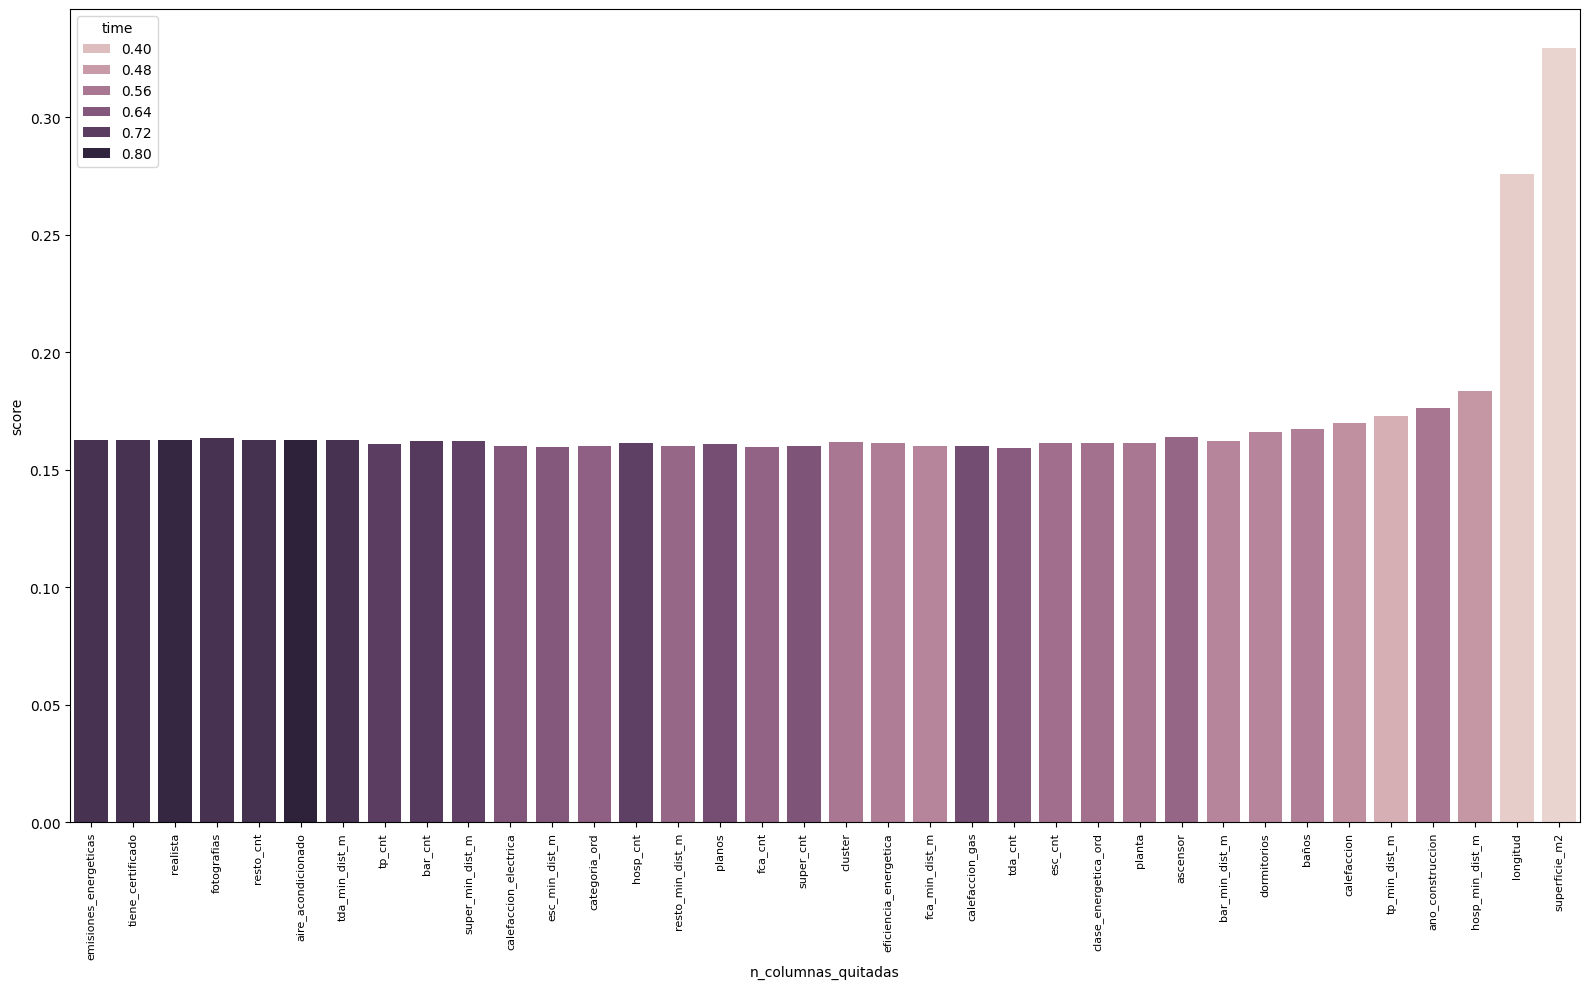

In [162]:
res = resultados_funcion.T.reset_index().reset_index()

res['score'] = res['score'] * -1
res['level_0'] = res['level_0'] + 1

res = res.rename(columns={'level_0': 'n_columnas_quitadas'})

# res['level_0_bin'] = pd.cut(res['level_0'], bins=3)

# sns.barplot(res, x='n_columnas_quitadas', y='score', hue='time')

plt.figure(figsize=(16, 10))
ax = sns.barplot(res, x='n_columnas_quitadas', y='score', hue='time')

ax.set_xticks(range(len(res)))
ax.set_xticklabels(res['index'], rotation=90)
ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()

In [191]:
columnas_a_quitar = resultados_funcion.T[:36].index.to_list()

X_train_opt = X_train_limpio.drop(columns=columnas_a_quitar)

X_train_opt

,latitud
788,40.377002
665,40.446802
296,40.489802
567,40.421302
679,40.646702
...,...
1044,40.481702
1095,40.478202
1130,39.859802
860,40.317202


In [42]:
def objective_xgb(trial):
    
    xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
    pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])

    params = {
        'model__n_estimators': trial.suggest_int('model__n_estimators', 500, 1200),
        'model__learning_rate': trial.suggest_float('model__learning_rate', 0.01, 0.15, log=True),
        'model__max_depth': trial.suggest_int('model__max_depth', 4, 8),
        'model__min_child_weight': trial.suggest_int('model__min_child_weight', 1, 5),
        'model__subsample': trial.suggest_float('model__subsample', 0.7, 1.0),
        'model__colsample_bytree': trial.suggest_float('model__colsample_bytree', 0.7, 1.0),
        'model__reg_alpha': trial.suggest_float('model__reg_alpha', 1e-3, 1.0, log=True),
        'model__reg_lambda': trial.suggest_float('model__reg_lambda', 1.0, 5.0),
    }
    
    pipe_xgb.set_params(**params)
    
    pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)
    
    score = cross_val_score(
        pipe_xgb_log,
        X_train_opt,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1
    ).mean()
    
    return score

study_xgb = create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100)

best_params_xgb = study_xgb.best_params
best_params_xgb

[I 2026-03-01 20:10:58,805] A new study created in memory with name: no-name-32992e56-1a60-4a94-95a9-ff84efcd4bf3
[W 2026-03-01 20:10:58,807] Trial 0 failed with parameters: {'model__n_estimators': 1003, 'model__learning_rate': 0.03333903186696641, 'model__max_depth': 8, 'model__min_child_weight': 2, 'model__subsample': 0.7807081090524508, 'model__colsample_bytree': 0.8626760142605077, 'model__reg_alpha': 0.3660722014387644, 'model__reg_lambda': 4.444020594067062} because of the following error: NameError("name 'X_train_opt' is not defined").
Traceback (most recent call last):
  File "c:\Users\phbas\Documents\Bootcamp_Data_Science\ML_Prediccion_Precio_Vivienda_Madrid\venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\phbas\AppData\Local\Temp\ipykernel_19932\758723064.py", line 23, in objective_xgb
    X_train_opt,
    ^^^^^^^^^^^
NameError: name 'X_train_opt' is not defined
[W 2

NameError: name 'X_train_opt' is not defined

26 -> 0.1590

27 -> 0.1600

28 -> 0.1584

29 -> 0.1693

30 -> 0.1648

31 -> 0.1674

32 -> 0.1701

33 -> 0.1727

34 -> 0.1769

35 -> 0.2478

36 -> 0.3059

Entre las conclusiones podemos decir que el entrenar el modelo como un pipeline completo es muy beneficioso para dejar un modelo listo para producción y totalmente automatizado, con la minima posibilidad de error, pero también conviene destacar que durante las pruebas y para la optimización de hiperparametros castiga mucho el primer paso del pipeline que tiene que desgranar las features y eso le lleva el mayor tiempo de todos los procesos siendo siempre el mismo proceso y resultado, habría que estudiar si podemos hacer este paso antes para que no forme parte del todo del pipeline...